# Описание проекта

### Ссылка на репозиторий проекта на GitHub
[https://github.com/Kiryl-92/project_marketing.git)

**Проект:** прогнозирование покупок в интернет-магазине

**Цель:** разработка модели машинного обучения для предсказания вероятности совершения покупки клиентом в течение следующих 90 дней на основе истории покупок и взаимодействия с рекламными рассылками.

**Задачи:**

- Исследование и предобработка данных о покупках клиентов (история заказов, категории товаров, цены, количество)
- Анализ данных о рекламных рассылках (типы событий, каналы коммуникации, временные характеристики)
- Разработка признаков, учитывающих поведенческие паттерны клиентов и особенности иерархической структуры категорий
- Обучение модели бинарной классификации для определения вероятности целевого события
- Оптимизация модели и максимизация метрики ROC-AUC
- Создание воспроизводимого пайплайна обработки данных и обучения модели
- Подготовка документации и обеспечение воспроизводимости результатов

**Источники данных:**

- apparel-purchases — история покупок клиентов (client_id, товары, цены, категории, дата, message_id)
- apparel-messages — история рекламных рассылок (client_id, кампания, тип события, канал, дата)
- full_campaign_daily_event — агрегированная статистика по рассылкам (события по дням)
- full_campaign_daily_event_channel — агрегированная статистика по рассылкам с разбивкой по каналам
- target — целевая переменная (совершил ли клиент покупку в целевом периоде)

**Метрика качества:** ROC-AUC — как стандартная метрика для задач бинарной классификации с возможным дисбалансом классов

Импортируем используемые библиотеки и фиксируем константы:

In [1]:
pip install -q phik

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install -q shap

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install -q catboost

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install -q scikit-optimize

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

import ast
from collections import Counter

from scipy import stats
import phik
from phik.report import plot_correlation_matrix

from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from scipy.stats import shapiro

import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE=42

/opt/homebrew/Cellar/jupyterlab/4.5.2/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Настроим отображения:

In [7]:
pd.set_option('display.max_columns', None)
%matplotlib inline

# Шаг 1. Загрузка данных

1.1 Загрузим данные в датафреймы pandas

In [8]:
pth1 = '/Users/klemba/project_marketing/filtered_data/apparel-purchases.csv'
pth2 = '***' # вставить возможный альтернативный путь (при необходимости)

if os.path.exists(pth1):
    apparel_purchases = pd.read_csv(pth1, sep=',')
elif os.path.exists(pth2):
    apparel_purchases = pd.read_csv(pth2, sep=',')
else:
    print('Something is wrong')

In [9]:
pth1 = '/Users/klemba/project_marketing/filtered_data/apparel-messages.csv'
pth2 = '***' # вставить возможный альтернативный путь (при необходимости)

if os.path.exists(pth1):
    apparel_messages = pd.read_csv(pth1, sep=',')
elif os.path.exists(pth2):
    apparel_messages = pd.read_csv(pth2, sep=',')
else:
    print('Something is wrong')

In [10]:
pth1 = '/Users/klemba/project_marketing/filtered_data/apparel-target_binary.csv'
pth2 = '***' # вставить возможный альтернативный путь (при необходимости)

if os.path.exists(pth1):
    apparel_target_binary = pd.read_csv(pth1, sep=',')
elif os.path.exists(pth2):
    apparel_target_binary = pd.read_csv(pth2, sep=',')
else:
    print('Something is wrong')

In [11]:
pth1 = '/Users/klemba/project_marketing/filtered_data/full_campaign_daily_event.csv'
pth2 = '***' # вставить возможный альтернативный путь (при необходимости)

if os.path.exists(pth1):
    full_campaign_daily_event = pd.read_csv(pth1, sep=',')
elif os.path.exists(pth2):
    full_campaign_daily_event = pd.read_csv(pth2, sep=',')
else:
    print('Something is wrong')

In [12]:
pth1 = '/Users/klemba/project_marketing/filtered_data/full_campaign_daily_event_channel.csv'
pth2 = '***' # вставить возможный альтернативный путь (при необходимости)

if os.path.exists(pth1):
    full_campaign_daily_event_channel = pd.read_csv(pth1, sep=',')
elif os.path.exists(pth2):
    full_campaign_daily_event_channel = pd.read_csv(pth2, sep=',')
else:
    print('Something is wrong')

1.2 Проверим данные в датафреймах

1.2.1 apparel_purchases

а. Выведим первые строки датафрейма и изучим общую информацию:

In [13]:
apparel_purchases.head()

,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [14]:
apparel_purchases.info()

<class 'pandas.DataFrame'>
RangeIndex: 202208 entries, 0 to 202207
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   client_id     202208 non-null  int64  
 1   quantity      202208 non-null  int64  
 2   price         202208 non-null  float64
 3   category_ids  202208 non-null  str    
 4   date          202208 non-null  str    
 5   message_id    202208 non-null  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 9.3 MB


**Краткий анализ датасета apparel_purchases:**

- Размерность: 202208 строк, 6 колонок
- Пропуски в данных отсутствуют
- Названия столбцов приведены к стандартному представлению (snake_case)
- Типы данных:

    - client_id и quantity — int64 (целое) - верный тип
    - price — float64 (дробное) - верный тип
    - category_ids и message_id — str (строка) - с учетом текущих данных верный тип, но можно произвести обработку данных
    - date — str (строка) - неверный тип - нужно изменить на тип дата



1.2.2 apparel_messages

а. Выведим первые строки датафрейма и изучим общую информацию:

In [15]:
apparel_messages.head(30)

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52
5,4439,1515915625594606468,1515915625594606468-4439-6283411f277fc,open,email,2022-05-19,2022-05-19 01:04:11
6,4439,1515915625491810918,1515915625491810918-4439-6283411d9d299,open,email,2022-05-19,2022-05-19 01:19:54
7,4439,1515915625474219766,1515915625474219766-4439-628341212233a,open,email,2022-05-19,2022-05-19 01:23:43
8,4439,1515915625474219766,1515915625474219766-4439-628341212233a,click,email,2022-05-19,2022-05-19 01:24:16
9,4439,1515915625566741491,1515915625566741491-4439-6283412871599,open,email,2022-05-19,2022-05-19 01:31:06


In [16]:
apparel_messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 12739798 entries, 0 to 12739797
Data columns (total 7 columns):
 #   Column            Dtype
---  ------            -----
 0   bulk_campaign_id  int64
 1   client_id         int64
 2   message_id        str  
 3   event             str  
 4   channel           str  
 5   date              str  
 6   created_at        str  
dtypes: int64(2), str(5)
memory usage: 680.4 MB


**Краткий анализ датасета apparel_messages:**

- Размерность: 12739798 строк, 7 колонок
- Названия столбцов приведены к стандартному представлению (snake_case)
- Типы данных:

    - bulk_campaign_id и client_id — int64 (целое) - верный тип
    - message_id — str (строка) - с учетом текущих данных верный тип, но можно произвести обработку данных
    - event и channel — str (строка) - верный тип
    - date и created_at — str (строка) - неверный тип - нужно изменить на тип дата



1.2.3 apparel_target_binary

а. Выведим первые строки датафрейма и изучим общую информацию:

In [17]:
apparel_target_binary.head()

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


In [18]:
apparel_target_binary.info()

<class 'pandas.DataFrame'>
RangeIndex: 49849 entries, 0 to 49848
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  49849 non-null  int64
 1   target     49849 non-null  int64
dtypes: int64(2)
memory usage: 779.0 KB


**Краткий анализ датасета apparel_target_binary:**

- Размерность: 49849 строк, 2 колонки
- Пропуски в данных отсутствуют
- Названия столбцов приведены к стандартному представлению (snake_case)
- Типы данных: client_id и target — int64 (целое) - верный тип



1.2.4 full_campaign_daily_event

а. Выведим первые строки датафрейма и изучим общую информацию:

In [19]:
full_campaign_daily_event.head()

,date,bulk_campaign_id,count_click,count_complain,count_hard_bounce,count_open,count_purchase,count_send,count_soft_bounce,count_subscribe,count_unsubscribe,nunique_click,nunique_complain,nunique_hard_bounce,nunique_open,nunique_purchase,nunique_send,nunique_soft_bounce,nunique_subscribe,nunique_unsubscribe,count_hbq_spam,nunique_hbq_spam,count_close,nunique_close
0,2022-05-19,563,0,0,0,4,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [20]:
full_campaign_daily_event.info()

<class 'pandas.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   date                 131072 non-null  str  
 1   bulk_campaign_id     131072 non-null  int64
 2   count_click          131072 non-null  int64
 3   count_complain       131072 non-null  int64
 4   count_hard_bounce    131072 non-null  int64
 5   count_open           131072 non-null  int64
 6   count_purchase       131072 non-null  int64
 7   count_send           131072 non-null  int64
 8   count_soft_bounce    131072 non-null  int64
 9   count_subscribe      131072 non-null  int64
 10  count_unsubscribe    131072 non-null  int64
 11  nunique_click        131072 non-null  int64
 12  nunique_complain     131072 non-null  int64
 13  nunique_hard_bounce  131072 non-null  int64
 14  nunique_open         131072 non-null  int64
 15  nunique_purchase     131072 non-null  int64
 16  nunique_send 

**Краткий анализ датасета full_campaign_daily_event:**

- Размерность: 131072 строк, 24 колонки
- Пропуски в данных отсутствуют
- Названия столбцов приведены к стандартному представлению (snake_case)
- Типы данных:

    - date — str (строка) - неверный тип - нужно изменить на тип дата
    - остальные показатели — int64 (целое) - верный тип


1.2.5 full_campaign_daily_event_channel

а. Выведим первые строки датафрейма и изучим общую информацию:

In [21]:
full_campaign_daily_event_channel.head()

,date,bulk_campaign_id,count_click_email,count_click_mobile_push,count_open_email,count_open_mobile_push,count_purchase_email,count_purchase_mobile_push,count_soft_bounce_email,count_subscribe_email,count_unsubscribe_email,nunique_click_email,nunique_click_mobile_push,nunique_open_email,nunique_open_mobile_push,nunique_purchase_email,nunique_purchase_mobile_push,nunique_soft_bounce_email,nunique_subscribe_email,nunique_unsubscribe_email,count_hard_bounce_mobile_push,count_send_mobile_push,nunique_hard_bounce_mobile_push,nunique_send_mobile_push,count_hard_bounce_email,count_hbq_spam_email,count_send_email,nunique_hard_bounce_email,nunique_hbq_spam_email,nunique_send_email,count_soft_bounce_mobile_push,nunique_soft_bounce_mobile_push,count_complain_email,nunique_complain_email,count_close_mobile_push,nunique_close_mobile_push
0,2022-05-19,563,0,0,4,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [22]:
full_campaign_daily_event_channel.info()

<class 'pandas.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   date                             131072 non-null  str  
 1   bulk_campaign_id                 131072 non-null  int64
 2   count_click_email                131072 non-null  int64
 3   count_click_mobile_push          131072 non-null  int64
 4   count_open_email                 131072 non-null  int64
 5   count_open_mobile_push           131072 non-null  int64
 6   count_purchase_email             131072 non-null  int64
 7   count_purchase_mobile_push       131072 non-null  int64
 8   count_soft_bounce_email          131072 non-null  int64
 9   count_subscribe_email            131072 non-null  int64
 10  count_unsubscribe_email          131072 non-null  int64
 11  nunique_click_email              131072 non-null  int64
 12  nunique_click_mobile_push        131072 n

**Краткий анализ датасета full_campaign_daily_event_channel:**

- Размерность: 131072 строк, 36 колонок
- Пропуски в данных отсутствуют
- Названия столбцов приведены к стандартному представлению (snake_case)
- Типы данных:

    - date — str (строка) - неверный тип - нужно изменить на тип дата
    - остальные показатели — int64 (целое) - верный тип


# Шаг 2. Предобработка данных

2.1 apparel_purchases

2.1.1 Преобразуем тип данных

In [23]:
apparel_purchases['date'] = pd.to_datetime(apparel_purchases['date'], format='%Y-%m-%d')
# Проверим результат
print("\napparel_purchases['date'].dtypes: ", apparel_purchases['date'].dtypes)


apparel_purchases['date'].dtypes:  datetime64[us]


2.1.2 Проверим и удалим полные дубликаты строк (при их наличии)

In [24]:
# Функция для проверки дубликатов
def check_duplicates(df):
    print(f"  Размер до удаления: {df.shape}")
    
    # Полные дубликаты (по всем колонкам)
    full_duplicates = df.duplicated(keep=False)
    full_duplicates_count = full_duplicates.sum()
    
    if full_duplicates_count > 0:
        print(f"  Найдено строк с дубликатами: {full_duplicates_count}")
        
        # Покажем примеры дубликатов
        duplicate_examples = df[full_duplicates].head(10)
        print(f"\n  Примеры дубликатов (первые 10 строк):")
        print(duplicate_examples)
        
        # Удаляем дубликаты
        df_clean = df.drop_duplicates().copy()
        print(f"  Размер после удаления: {df_clean.shape}")
        print(f"  Удалено строк: {df.shape[0] - df_clean.shape[0]}")
        return df_clean
    else:
        print("  Дубликаты не найдены")
        return df.copy()

In [25]:
apparel_purchases_clean = check_duplicates(apparel_purchases)

  Размер до удаления: (202208, 6)
  Найдено строк с дубликатами: 131683

  Примеры дубликатов (первые 10 строк):
              client_id  quantity   price                     category_ids  \
11  1515915625491869271         2   599.0       ['4', '27', '350', '1392']   
12  1515915625491869271         2   599.0       ['4', '27', '350', '1392']   
21  1515915625566606509         1   299.0  ['5562', '5634', '5579', '710']   
22  1515915625566606509         1   299.0  ['5562', '5634', '5579', '710']   
41  1515915625468070175         1  2199.0        ['4', '27', '142', '496']   
42  1515915625468070175         1  2199.0        ['4', '27', '142', '496']   
58  1515915625468126078         1  1499.0        ['4', '28', '275', '421']   
59  1515915625468126078         1  1499.0        ['4', '28', '275', '421']   
61  1515915625468141317         1    49.0         ['4', '27', '38', '481']   
62  1515915625468141317         1    49.0         ['4', '27', '38', '481']   

         date               

Сохраняем очищенную версию обратно в исходные переменные:

In [26]:
apparel_purchases = apparel_purchases_clean

2.1.3 Проанализируем и обработаем category_ids

Преобразуем category_ids в список:

In [27]:
apparel_purchases['category_ids_list'] = apparel_purchases['category_ids'].apply(ast.literal_eval)
apparel_purchases['category_ids_list'].head()

0     [4, 28, 57, 431]
1     [4, 28, 57, 431]
2     [4, 28, 57, 431]
3    [4, 28, 244, 432]
4     [4, 28, 49, 413]
Name: category_ids_list, dtype: object

Проанализируем структуру категорий:

In [28]:
category_lengths = apparel_purchases['category_ids_list'].apply(len)
print(f"\n1. Количество уровней вложенности:")
print(f"   Минимум: {category_lengths.min()}")
print(f"   Максимум: {category_lengths.max()}")
print(f"\n   Распределение:")
print(category_lengths.value_counts().sort_index())


1. Количество уровней вложенности:
   Минимум: 0
   Максимум: 5

   Распределение:
category_ids_list
0      2738
1       622
3       736
4    124747
5       345
Name: count, dtype: int64


In [29]:
apparel_purchases[apparel_purchases['category_ids_list'].apply(len)==0].head()

,client_id,quantity,price,category_ids,date,message_id,category_ids_list
22153,1515915625558323436,1,1.0,[],2022-07-09,1515915625487742246-5335-62c7d2d1281c7,[]
49215,1515915625474537721,1,7.0,[],2022-11-12,1515915625474537721-7803-636dfed5eb8b6,[]
53223,1515915625720375281,1,5.0,[],2022-11-13,1515915625720375281-7818-636f6ec29a382,[]
59056,1515915625867975448,1,7.0,[],2022-11-16,1515915625766044118-7879-63748749d81b5,[]
60268,1515915625489294901,1,7.0,[],2022-11-23,1515915625489294901-8033-637dbe1f75aa9,[]


In [30]:
apparel_purchases[apparel_purchases['category_ids_list'].apply(len)==1].head()

,client_id,quantity,price,category_ids,date,message_id,category_ids_list
14848,1515915625649908756,1,2499.0,[None],2022-06-17,1515915625649908756-4981-62ac2dbf52fad,[None]
32281,1515915625578652401,1,8.0,[None],2022-08-19,1515915625815834300-5922-62ff35494e05f,[None]
32283,1515915625578652401,1,1.0,[None],2022-08-19,1515915625815834300-5922-62ff35494e05f,[None]
33447,1515915625468141353,1,7.0,[None],2022-08-25,1515915625468141353-5922-62ff3544b2556,[None]
33982,1515915625468112307,1,3.0,[None],2022-08-29,1515915625468112307-6223-630c9088d251c,[None]


In [31]:
apparel_purchases[apparel_purchases['category_ids_list'].apply(len)==3].head()

,client_id,quantity,price,category_ids,date,message_id,category_ids_list
55348,1515915625489465791,1,193.0,"['4', '44', '428']",2022-11-15,1515915625489465791-7845-6373358bbb68e,"[4, 44, 428]"
56942,1515915625602272264,1,28.0,"['4', '44', '1594']",2022-11-15,1515915625491914808-7845-637335966f02d,"[4, 44, 1594]"
57592,1515915625468142032,1,39.0,"['4', '44', '1594']",2022-11-16,1515915625468142032-7816-6371eb13cdaed,"[4, 44, 1594]"
58626,1515915625597238880,1,174.0,"['4', '44', '989']",2022-11-16,1515915625597238880-7882-637397ee60ebb,"[4, 44, 989]"
59235,1515915625588553267,1,70.0,"['4', '44', '489']",2022-11-17,1515915625588553267-7896-63749f9575d8d,"[4, 44, 489]"


In [32]:
apparel_purchases[apparel_purchases['category_ids_list'].apply(len)==4].head()

,client_id,quantity,price,category_ids,date,message_id,category_ids_list
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d,"[4, 28, 57, 431]"
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d,"[4, 28, 57, 431]"
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843,"[4, 28, 57, 431]"
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843,"[4, 28, 244, 432]"
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843,"[4, 28, 49, 413]"


In [33]:
apparel_purchases[apparel_purchases['category_ids_list'].apply(len)==5].head()

,client_id,quantity,price,category_ids,date,message_id,category_ids_list
1703,1515915625605245612,1,1499.0,"['2', '17', '330', '387', '467']",2022-05-20,1515915625605245612-4492-62873cca6dd23,"[2, 17, 330, 387, 467]"
1727,1515915625637984750,1,1599.0,"['2', '17', '330', '387', '467']",2022-05-20,1515915625637984750-4492-62873cd797f2a,"[2, 17, 330, 387, 467]"
2093,1515915625642188604,1,1799.0,"['2', '17', '330', '387', '467']",2022-05-21,1515915625557272200-3557-623d68b1ecb7f,"[2, 17, 330, 387, 467]"
2794,1515915625623306912,1,999.0,"['2', '17', '330', '387', '467']",2022-05-23,1515915625623306912-4492-62873cd587294,"[2, 17, 330, 387, 467]"
4827,1515915625487831171,1,4499.0,"['2', '17', '330', '387', '467']",2022-06-01,1515915625487831171-4679-62972204a71a4,"[2, 17, 330, 387, 467]"


Исследуем значения category_ids_list, длина которых равна 1:

In [34]:
apparel_purchases[apparel_purchases['category_ids_list'].apply(len)==1]['category_ids_list'].value_counts()

category_ids_list
[None]    622
Name: count, dtype: int64

**Комментарий:** имеются пропуску в category_ids - при длине category_ids_list равной 0 или 1. Всего таких строк (2738+622)=3360 или 2,6%. Предлагаю удалить данные строки, что некритично для анализа.

In [35]:
print(f"  Размер apparel_purchases до удаления: {apparel_purchases.shape}")
apparel_purchases = apparel_purchases[apparel_purchases['category_ids_list'].apply(len)>1]
print(f"  Размер apparel_purchases после удаления: {apparel_purchases.shape}")

  Размер apparel_purchases до удаления: (129188, 7)
  Размер apparel_purchases после удаления: (125828, 7)


In [36]:
category_lengths = apparel_purchases['category_ids_list'].apply(len)
print(f"\n1. Количество уровней вложенности:")
print(f"   Минимум: {category_lengths.min()}")
print(f"   Максимум: {category_lengths.max()}")
print(f"\n   Распределение:")
print(category_lengths.value_counts().sort_index())


1. Количество уровней вложенности:
   Минимум: 3
   Максимум: 5

   Распределение:
category_ids_list
3       736
4    124747
5       345
Name: count, dtype: int64


Приверим все уникальные категории из списков:

In [37]:
all_categories = set()
for cat_list in apparel_purchases['category_ids_list']:
    all_categories.update([str(cat) for cat in cat_list])

print(f"Всего уникальных категорий: {len(all_categories)}")

Всего уникальных категорий: 1151


Анализ первого уровня:

In [38]:
first_level = apparel_purchases['category_ids_list'].apply(lambda x: x[0])
print("\n4. Распределение первого уровня:")
print(first_level.value_counts())


4. Распределение первого уровня:
category_ids_list
4       73428
5562    29148
2       17995
6060     4458
5963      789
3           6
1           3
5           1
Name: count, dtype: int64


**Комментарий:** предлагаю для категорий первого уровня создать бинарные признаки. Это позволит выделить ключевые категории как отдельные признаки.

Список категорий первого уровня для выделения:

In [39]:
top_categories = first_level.unique()
category_names = [f'category_id_{cat}' for cat in top_categories]

Создаем бинарные признаки:

In [40]:
for cat in top_categories:
    col_name = f'category_id_{cat}'
    apparel_purchases[col_name] = apparel_purchases['category_ids_list'].apply(
        lambda x: 1 if cat in [str(c) for c in x] else 0
    )

Удаляем лишние столбцы:

In [41]:
apparel_purchases = apparel_purchases.drop(columns=['category_ids', 'category_ids_list'])

In [42]:
apparel_purchases.head()

,client_id,quantity,price,date,message_id,category_id_4,category_id_2,category_id_5562,category_id_1,category_id_5963,category_id_3,category_id_6060,category_id_5
0,1515915625468169594,1,1999.0,2022-05-16,1515915625468169594-4301-627b661e9736d,1,0,0,0,0,0,0,0
1,1515915625468169594,1,2499.0,2022-05-16,1515915625468169594-4301-627b661e9736d,1,0,0,0,0,0,0,0
2,1515915625471138230,1,6499.0,2022-05-16,1515915625471138230-4437-6282242f27843,1,0,0,0,0,0,0,0
3,1515915625471138230,1,4999.0,2022-05-16,1515915625471138230-4437-6282242f27843,1,0,0,0,0,0,0,0
4,1515915625471138230,1,4999.0,2022-05-16,1515915625471138230-4437-6282242f27843,1,0,0,0,0,0,0,0


In [43]:
apparel_purchases.info()

<class 'pandas.DataFrame'>
Index: 125828 entries, 0 to 202207
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   client_id         125828 non-null  int64         
 1   quantity          125828 non-null  int64         
 2   price             125828 non-null  float64       
 3   date              125828 non-null  datetime64[us]
 4   message_id        125828 non-null  str           
 5   category_id_4     125828 non-null  int64         
 6   category_id_2     125828 non-null  int64         
 7   category_id_5562  125828 non-null  int64         
 8   category_id_1     125828 non-null  int64         
 9   category_id_5963  125828 non-null  int64         
 10  category_id_3     125828 non-null  int64         
 11  category_id_6060  125828 non-null  int64         
 12  category_id_5     125828 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(10), str(1)
memory usage: 13.4 MB


**Комментарий:** бинарные признаки созданы и соответветствующие значения категорий удалены из списка. 

2.1.4 создадим новый столбец cost

In [44]:
apparel_purchases['cost'] = apparel_purchases['quantity'] * apparel_purchases['price']
apparel_purchases.head()

,client_id,quantity,price,date,message_id,category_id_4,category_id_2,category_id_5562,category_id_1,category_id_5963,category_id_3,category_id_6060,category_id_5,cost
0,1515915625468169594,1,1999.0,2022-05-16,1515915625468169594-4301-627b661e9736d,1,0,0,0,0,0,0,0,1999.0
1,1515915625468169594,1,2499.0,2022-05-16,1515915625468169594-4301-627b661e9736d,1,0,0,0,0,0,0,0,2499.0
2,1515915625471138230,1,6499.0,2022-05-16,1515915625471138230-4437-6282242f27843,1,0,0,0,0,0,0,0,6499.0
3,1515915625471138230,1,4999.0,2022-05-16,1515915625471138230-4437-6282242f27843,1,0,0,0,0,0,0,0,4999.0
4,1515915625471138230,1,4999.0,2022-05-16,1515915625471138230-4437-6282242f27843,1,0,0,0,0,0,0,0,4999.0


In [45]:
apparel_purchases.info()

<class 'pandas.DataFrame'>
Index: 125828 entries, 0 to 202207
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   client_id         125828 non-null  int64         
 1   quantity          125828 non-null  int64         
 2   price             125828 non-null  float64       
 3   date              125828 non-null  datetime64[us]
 4   message_id        125828 non-null  str           
 5   category_id_4     125828 non-null  int64         
 6   category_id_2     125828 non-null  int64         
 7   category_id_5562  125828 non-null  int64         
 8   category_id_1     125828 non-null  int64         
 9   category_id_5963  125828 non-null  int64         
 10  category_id_3     125828 non-null  int64         
 11  category_id_6060  125828 non-null  int64         
 12  category_id_5     125828 non-null  int64         
 13  cost              125828 non-null  float64       
dtypes: datetime64[us](1)

In [46]:
apparel_purchases.sort_values(by='client_id').head(30)

,client_id,quantity,price,date,message_id,category_id_4,category_id_2,category_id_5562,category_id_1,category_id_5963,category_id_3,category_id_6060,category_id_5,cost
3697,1515915625468060902,1,1299.0,2022-05-27,1515915625468060902-4617-6290657dac196,1,0,0,0,0,0,0,0,1299.0
3695,1515915625468060902,1,199.0,2022-05-27,1515915625468060902-4617-6290657dac196,1,0,0,0,0,0,0,0,199.0
3696,1515915625468060902,1,1999.0,2022-05-27,1515915625468060902-4617-6290657dac196,1,0,0,0,0,0,0,0,1999.0
3700,1515915625468060902,1,299.0,2022-05-27,1515915625468060902-4617-6290657dac196,1,0,0,0,0,0,0,0,299.0
3701,1515915625468060902,1,999.0,2022-05-27,1515915625468060902-4617-6290657dac196,1,0,0,0,0,0,0,0,999.0
81798,1515915625468061003,1,2099.0,2023-01-04,1515915625468061003-9148-63b54b04855a4,1,0,0,0,0,0,0,0,2099.0
81797,1515915625468061003,1,2449.0,2023-01-04,1515915625468061003-9148-63b54b04855a4,1,0,0,0,0,0,0,0,2449.0
81796,1515915625468061003,1,1749.0,2023-01-04,1515915625468061003-9148-63b54b04855a4,1,0,0,0,0,0,0,0,1749.0
81795,1515915625468061003,1,2239.0,2023-01-04,1515915625468061003-9148-63b54b04855a4,1,0,0,0,0,0,0,0,2239.0
81793,1515915625468061003,1,2100.0,2023-01-04,1515915625468061003-9148-63b54b04855a4,1,0,0,0,0,0,0,0,2100.0


2.1.5 На основе apparel_purchases создадим агрегированную таблицу по client_id:

Агрегация числовых признаков:

In [47]:
numeric_agg = apparel_purchases.groupby('client_id').agg({
    'cost': 'sum',              # общая сумма покупок
    'quantity': 'sum',          # общее количество товаров
    'price': 'mean',            # средняя цена товара
}).round(1)

In [48]:
numeric_agg = numeric_agg.reset_index()
print(f"   Создано признаков: {numeric_agg.shape[1] - 1}")
numeric_agg.head()

   Создано признаков: 3


,client_id,cost,quantity,price
0,1515915625468060902,4795.0,5,959.0
1,1515915625468061003,14135.0,6,2355.8
2,1515915625468061099,299.0,1,299.0
3,1515915625468061100,1049.0,1,1049.0
4,1515915625468061170,14095.0,7,2013.6


Суммируем бинарные категории (сколько раз клиент покупал товары каждой категории)

Получаем список бинарных столбцов с категориями:

In [49]:
category_cols = [col for col in apparel_purchases.columns if col.startswith('category_id_')]
print(f"Найдено бинарных категорий: {len(category_cols)}")
print(f"Категории: {category_cols}")

Найдено бинарных категорий: 8
Категории: ['category_id_4', 'category_id_2', 'category_id_5562', 'category_id_1', 'category_id_5963', 'category_id_3', 'category_id_6060', 'category_id_5']


In [50]:
category_agg = apparel_purchases.groupby('client_id')[category_cols].sum().reset_index()

# Переименовываем колонки для ясности
category_agg.columns = ['client_id'] + [f'{col}_count' for col in category_cols]

print(f"   Создано признаков: {category_agg.shape[1] - 1}")
print(category_agg.head())

   Создано признаков: 8
             client_id  category_id_4_count  category_id_2_count  \
0  1515915625468060902                    5                    0   
1  1515915625468061003                    6                    0   
2  1515915625468061099                    1                    0   
3  1515915625468061100                    1                    0   
4  1515915625468061170                    6                    1   

   category_id_5562_count  category_id_1_count  category_id_5963_count  \
0                       0                    0                       0   
1                       0                    0                       0   
2                       0                    0                       0   
3                       0                    0                       0   
4                       0                    0                       0   

   category_id_3_count  category_id_6060_count  category_id_5_count  
0                    0                       0      

Количество уникальных дней с покупками:

In [51]:
unique_dates_agg = apparel_purchases.groupby('client_id')['date'].nunique().reset_index()
unique_dates_agg.columns = ['client_id', 'unique_purchase_days']

print(f"   Создано признаков: {unique_dates_agg.shape[1] - 1}")
print(unique_dates_agg.head())

   Создано признаков: 1
             client_id  unique_purchase_days
0  1515915625468060902                     1
1  1515915625468061003                     1
2  1515915625468061099                     1
3  1515915625468061100                     1
4  1515915625468061170                     3


Количество уникальных message_id для каждого клиента:

In [52]:
unique_messages_agg = apparel_purchases.groupby('client_id')['message_id'].nunique().reset_index()
unique_messages_agg.columns = ['client_id', 'unique_messages']

print(f"   Создано признаков: {unique_messages_agg.shape[1] - 1}")
print(unique_messages_agg.head())

   Создано признаков: 1
             client_id  unique_messages
0  1515915625468060902                1
1  1515915625468061003                1
2  1515915625468061099                1
3  1515915625468061100                1
4  1515915625468061170                3


Объединяем все части в итоговый датафрейм:

In [53]:
apparel_purchases_agg = numeric_agg.merge(category_agg, on='client_id', how='left')
apparel_purchases_agg = apparel_purchases_agg.merge(unique_dates_agg, on='client_id', how='left')
apparel_purchases_agg = apparel_purchases_agg.merge(unique_messages_agg, on='client_id', how='left')

print(f"   Итоговый размер: {apparel_purchases_agg.shape}")
print(f"   Всего признаков: {apparel_purchases_agg.shape[1]}")

apparel_purchases_agg.head()

   Итоговый размер: (49848, 14)
   Всего признаков: 14


,client_id,cost,quantity,price,category_id_4_count,category_id_2_count,category_id_5562_count,category_id_1_count,category_id_5963_count,category_id_3_count,category_id_6060_count,category_id_5_count,unique_purchase_days,unique_messages
0,1515915625468060902,4795.0,5,959.0,5,0,0,0,0,0,0,0,1,1
1,1515915625468061003,14135.0,6,2355.8,6,0,0,0,0,0,0,0,1,1
2,1515915625468061099,299.0,1,299.0,1,0,0,0,0,0,0,0,1,1
3,1515915625468061100,1049.0,1,1049.0,1,0,0,0,0,0,0,0,1,1
4,1515915625468061170,14095.0,7,2013.6,6,1,0,0,0,0,0,0,3,3


2.2 apparel_messages

2.2.1 Преобразуем тип данных

In [54]:
apparel_messages['date'] = pd.to_datetime(apparel_messages['date'], format='%Y-%m-%d')
apparel_messages['created_at'] = pd.to_datetime(apparel_messages['created_at'], format='%Y-%m-%d %H:%M:%S')

# Проверим результат
print("\napparel_messages['date'].dtypes: ", apparel_messages['date'].dtypes)
print("\napparel_messages['created_at'].dtypes: ", apparel_messages['created_at'].dtypes)


apparel_messages['date'].dtypes:  datetime64[us]

apparel_messages['created_at'].dtypes:  datetime64[us]


2.2.2 Проверим на наличие неявных дубликатов в ряде качественных признаков:

- показатель event:

In [55]:
apparel_messages['event'].unique()

<StringArray>
[       'open',       'click',    'purchase',        'send', 'unsubscribe',
    'hbq_spam', 'hard_bounce',   'subscribe', 'soft_bounce',    'complain',
       'close']
Length: 11, dtype: str

In [56]:
apparel_messages['event'].value_counts()

event
send           9058196
open           3085820
click           496339
purchase         64679
hard_bounce      19903
soft_bounce      10583
unsubscribe       2841
hbq_spam           823
complain           528
subscribe           85
close                1
Name: count, dtype: int64

- показатель channel:

In [57]:
apparel_messages['channel'].unique()

<StringArray>
['email', 'mobile_push']
Length: 2, dtype: str

In [58]:
apparel_messages['channel'].value_counts()

channel
mobile_push    7512156
email          5227642
Name: count, dtype: int64

**Комментарий:** неявные дубликаты отсутствуют.

2.2.3 Проверим и удалим полные дубликаты строк (при их наличии)

In [59]:
apparel_messages_clean = check_duplicates(apparel_messages)

  Размер до удаления: (12739798, 7)
  Найдено строк с дубликатами: 94519

  Примеры дубликатов (первые 10 строк):
        bulk_campaign_id            client_id  \
964231              5723  1515915625554535987   
964232              5723  1515915625554535987   
966465              5723  1515915625483569932   
966466              5723  1515915625483569932   
967281              5723  1515915625736038297   
967282              5723  1515915625736038297   
967566              5723  1515915625753898206   
967567              5723  1515915625753898206   
967903              5723  1515915625626349443   
967904              5723  1515915625626349443   

                                    message_id  event      channel       date  \
964231  1515915625554535987-5723-62e2af08e00da  click  mobile_push 2022-07-28   
964232  1515915625554535987-5723-62e2af08e00da  click  mobile_push 2022-07-28   
966465  1515915625483569932-5723-62e2af0790ad5  click  mobile_push 2022-07-28   
966466  15159156254835

Сохраняем очищенную версию обратно в исходные переменные:

In [60]:
apparel_messages = apparel_messages_clean

In [61]:
apparel_messages.head()

,bulk_campaign_id,client_id,message_id,event,channel,date,created_at
0,4439,1515915625626736623,1515915625626736623-4439-6283415ac07ea,open,email,2022-05-19,2022-05-19 00:14:20
1,4439,1515915625490086521,1515915625490086521-4439-62834150016dd,open,email,2022-05-19,2022-05-19 00:39:34
2,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,open,email,2022-05-19,2022-05-19 00:51:49
3,4439,1515915625553578558,1515915625553578558-4439-6283415b36b4f,click,email,2022-05-19,2022-05-19 00:52:20
4,4439,1515915625471518311,1515915625471518311-4439-628341570c133,open,email,2022-05-19,2022-05-19 00:56:52


2.2.4 На основе apparel_messages создадим агрегированную таблицу по client_id:

Колличество уникальных рассылок:

In [62]:
unique_bulk_campaign = apparel_messages.groupby('client_id')['bulk_campaign_id'].nunique().reset_index()
unique_bulk_campaign.columns = ['client_id', 'unique_bulk_campaign']

print(f"   Создано признаков: {unique_bulk_campaign.shape[1] - 1}")
print(unique_bulk_campaign.head())

   Создано признаков: 1
             client_id  unique_bulk_campaign
0  1515915625468060902                   127
1  1515915625468061003                   154
2  1515915625468061099                   215
3  1515915625468061100                   265
4  1515915625468061170                   240


Добавим статистику по типам событий:

In [63]:
event_stats = pd.crosstab(apparel_messages['client_id'], 
                          apparel_messages['event']).reset_index()

Переименовываем столбцы событий:

In [64]:
event_columns = {col: f'event_{col}' for col in event_stats.columns if col != 'client_id'}
event_stats = event_stats.rename(columns=event_columns)
event_stats.head()

event,client_id,event_click,event_close,event_complain,event_hard_bounce,event_hbq_spam,event_open,event_purchase,event_send,event_soft_bounce,event_subscribe,event_unsubscribe
0,1515915625468060902,10,0,0,0,0,35,5,126,0,0,1
1,1515915625468061003,5,0,0,0,0,5,1,154,0,0,0
2,1515915625468061099,8,0,0,2,0,51,0,215,0,0,0
3,1515915625468061100,1,0,0,1,0,157,1,267,1,0,0
4,1515915625468061170,16,0,0,0,0,31,3,243,0,0,0


Аналогично для статистики по каналам:

In [65]:
channel_stats = pd.crosstab(apparel_messages['client_id'], 
                           apparel_messages['channel']).reset_index()
channel_columns = {col: f'channel_{col}' for col in channel_stats.columns if col != 'client_id'}
channel_stats = channel_stats.rename(columns=channel_columns)
channel_stats.head()

channel,client_id,channel_email,channel_mobile_push
0,1515915625468060902,177,0
1,1515915625468061003,165,0
2,1515915625468061099,182,94
3,1515915625468061100,0,428
4,1515915625468061170,202,91


Создаем сводную таблицу с событиями для расчета конверсий:

In [66]:
event_pivot = apparel_messages.pivot_table(
    index='client_id',
    columns='event',
    aggfunc='size',
    fill_value=0
).reset_index()

# Переименовываем колонки
event_pivot.columns = ['client_id'] + [f'conv_{col}' for col in event_pivot.columns[1:]]

# Рассчитываем конверсии (осторожно с делением на 0)
event_pivot['conv_open_to_click'] = (event_pivot['conv_click'] / event_pivot['conv_open']).replace([np.inf, -np.inf], 0).fillna(0)
event_pivot['conv_click_to_purchase'] = (event_pivot['conv_purchase'] / event_pivot['conv_click']).replace([np.inf, -np.inf], 0).fillna(0)
event_pivot['conv_open_to_purchase'] = (event_pivot['conv_purchase'] / event_pivot['conv_open']).replace([np.inf, -np.inf], 0).fillna(0)
event_pivot['conv_send_to_open'] = (event_pivot['conv_open'] / event_pivot['conv_send']).replace([np.inf, -np.inf], 0).fillna(0)

# Создаем event_pivot ТОЛЬКО с новыми конверсионными метриками
event_pivot_conversions = event_pivot[['client_id', 
                                       'conv_open_to_click', 
                                       'conv_click_to_purchase', 
                                       'conv_open_to_purchase', 
                                       'conv_send_to_open']].copy()

Объединяем все части в итоговый датафрейм:

In [67]:
apparel_messages_agg = unique_bulk_campaign.merge(event_stats, on='client_id', how='left')
apparel_messages_agg = apparel_messages_agg.merge(channel_stats, on='client_id', how='left')
apparel_messages_agg = apparel_messages_agg.merge(event_pivot_conversions, on='client_id', how='left')

print(f"   Итоговый размер: {apparel_messages_agg.shape}")
print(f"   Всего признаков: {apparel_messages_agg.shape[1]}")

apparel_messages_agg.head()


   Итоговый размер: (53329, 19)
   Всего признаков: 19


,client_id,unique_bulk_campaign,event_click,event_close,event_complain,event_hard_bounce,event_hbq_spam,event_open,event_purchase,event_send,event_soft_bounce,event_subscribe,event_unsubscribe,channel_email,channel_mobile_push,conv_open_to_click,conv_click_to_purchase,conv_open_to_purchase,conv_send_to_open
0,1515915625468060902,127,10,0,0,0,0,35,5,126,0,0,1,177,0,0.285714,0.5000,0.142857,0.277778
1,1515915625468061003,154,5,0,0,0,0,5,1,154,0,0,0,165,0,1.000000,0.2000,0.200000,0.032468
2,1515915625468061099,215,8,0,0,2,0,51,0,215,0,0,0,182,94,0.156863,0.0000,0.000000,0.237209
3,1515915625468061100,265,1,0,0,1,0,157,1,267,1,0,0,0,428,0.006369,1.0000,0.006369,0.588015
4,1515915625468061170,240,16,0,0,0,0,31,3,243,0,0,0,202,91,0.516129,0.1875,0.096774,0.127572


2.3 apparel_target_binary

Проверим и удалим полные дубликаты строк (при их наличии)

In [68]:
apparel_target_binary_clean = check_duplicates(apparel_target_binary)

  Размер до удаления: (49849, 2)
  Дубликаты не найдены


Сохраняем очищенную версию обратно в исходные переменные:

In [69]:
apparel_target_binary = apparel_target_binary_clean

In [70]:
apparel_target_binary.head()

,client_id,target
0,1515915625468060902,0
1,1515915625468061003,1
2,1515915625468061099,0
3,1515915625468061100,0
4,1515915625468061170,0


2.4 full_campaign_daily_event

2.4.1 Преобразуем тип данных

In [71]:
full_campaign_daily_event['date'] = pd.to_datetime(full_campaign_daily_event['date'], format='%Y-%m-%d')

# Проверим результат
print("\nfull_campaign_daily_event['date'].dtypes: ", full_campaign_daily_event['date'].dtypes)


full_campaign_daily_event['date'].dtypes:  datetime64[us]


2.4.2 Проверим и удалим полные дубликаты строк (при их наличии)

In [72]:
full_campaign_daily_event_clean = check_duplicates(full_campaign_daily_event)

  Размер до удаления: (131072, 24)
  Дубликаты не найдены


Сохраняем очищенную версию обратно в исходные переменные:

In [73]:
full_campaign_daily_event = full_campaign_daily_event_clean

In [74]:
full_campaign_daily_event.head()

,date,bulk_campaign_id,count_click,count_complain,count_hard_bounce,count_open,count_purchase,count_send,count_soft_bounce,count_subscribe,count_unsubscribe,nunique_click,nunique_complain,nunique_hard_bounce,nunique_open,nunique_purchase,nunique_send,nunique_soft_bounce,nunique_subscribe,nunique_unsubscribe,count_hbq_spam,nunique_hbq_spam,count_close,nunique_close
0,2022-05-19,563,0,0,0,4,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


2.5 full_campaign_daily_event_channel

2.5.1 Преобразуем тип данных

In [75]:
full_campaign_daily_event_channel['date'] = pd.to_datetime(full_campaign_daily_event_channel['date'], format='%Y-%m-%d')

# Проверим результат
print("\nfull_campaign_daily_event_channel['date'].dtypes: ", full_campaign_daily_event_channel['date'].dtypes)


full_campaign_daily_event_channel['date'].dtypes:  datetime64[us]


2.5.2 Проверим и удалим полные дубликаты строк (при их наличии)

In [76]:
full_campaign_daily_event_channel_clean = check_duplicates(full_campaign_daily_event_channel)

  Размер до удаления: (131072, 36)
  Дубликаты не найдены


Сохраняем очищенную версию обратно в исходные переменные:

In [77]:
full_campaign_daily_event_channel = full_campaign_daily_event_channel_clean

In [78]:
full_campaign_daily_event_channel.head()

,date,bulk_campaign_id,count_click_email,count_click_mobile_push,count_open_email,count_open_mobile_push,count_purchase_email,count_purchase_mobile_push,count_soft_bounce_email,count_subscribe_email,count_unsubscribe_email,nunique_click_email,nunique_click_mobile_push,nunique_open_email,nunique_open_mobile_push,nunique_purchase_email,nunique_purchase_mobile_push,nunique_soft_bounce_email,nunique_subscribe_email,nunique_unsubscribe_email,count_hard_bounce_mobile_push,count_send_mobile_push,nunique_hard_bounce_mobile_push,nunique_send_mobile_push,count_hard_bounce_email,count_hbq_spam_email,count_send_email,nunique_hard_bounce_email,nunique_hbq_spam_email,nunique_send_email,count_soft_bounce_mobile_push,nunique_soft_bounce_mobile_push,count_complain_email,nunique_complain_email,count_close_mobile_push,nunique_close_mobile_push
0,2022-05-19,563,0,0,4,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2022-05-19,577,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2022-05-19,622,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2022-05-19,634,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2022-05-19,676,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


2.6 Объединим три первых агрегированных таблицы в итоговый датафрейм и проверим на пропуски

Объединяем target с purchases (left join чтобы сохранить всех клиентов из target):

In [79]:
data = apparel_target_binary.merge(apparel_purchases_agg, on='client_id', how='left')

Добавляем messages (left join чтобы сохранить всех клиентов из target):

In [80]:
data = data.merge(apparel_messages_agg, on='client_id', how='left')

In [81]:
print(f"Размер до обработки пропусков: {data.shape}")
print(f"Всего признаков: {data.shape[1]}")

Размер до обработки пропусков: (49849, 33)
Всего признаков: 33


Обработаем пропуски (при их наличии):

Проверяем пропуски до обработки:

In [82]:
missing_before = data.isnull().sum().sum()
print(f"Всего пропусков до обработки: {missing_before}")

Всего пропусков до обработки: 141619


Определяем колонки для заполнения (все кроме target):

In [83]:
cols_to_fill = [col for col in data.columns if col != 'target']

Заполняем пропуски нулями (предложение, что человек ничего не покупал и не получал рассылки):

In [84]:
data[cols_to_fill] = data[cols_to_fill].fillna(0)

Проверяем пропуски после обработки:

In [85]:
missing_after = data.isnull().sum().sum()
print(f"Всего пропусков после обработки: {missing_after}")

Всего пропусков после обработки: 0


Создаем признак-индикатор отсутствия данных о рассылках:

In [86]:
data['has_bulk_campaign'] = (data['unique_bulk_campaign'] > 0).astype(int)
clients_without_bulk_campaign = len(data[data['has_bulk_campaign'] == 0])
print(f"\nКлиентов без данных о рассылках: {clients_without_bulk_campaign}")
print(f"Это {clients_without_bulk_campaign/len(data)*100:.2f}% от выборки")


Клиентов без данных о рассылках: 7867
Это 15.78% от выборки


Устанавливаем client_id как индекс:

In [87]:
data = data.set_index('client_id')

In [88]:
print("Итоговый датафрейм:")
print(f"Размер: {data.shape}")
print(f"Всего признаков: {data.shape[1]}")
print(f"Типы данных:\n{data.dtypes.value_counts()}")
print(f"\nПервые 5 строк:")
data.head()

Итоговый датафрейм:
Размер: (49849, 33)
Всего признаков: 33
Типы данных:
float64    31
int64       2
Name: count, dtype: int64

Первые 5 строк:


,target,cost,quantity,price,category_id_4_count,category_id_2_count,category_id_5562_count,category_id_1_count,category_id_5963_count,category_id_3_count,category_id_6060_count,category_id_5_count,unique_purchase_days,unique_messages,unique_bulk_campaign,event_click,event_close,event_complain,event_hard_bounce,event_hbq_spam,event_open,event_purchase,event_send,event_soft_bounce,event_subscribe,event_unsubscribe,channel_email,channel_mobile_push,conv_open_to_click,conv_click_to_purchase,conv_open_to_purchase,conv_send_to_open,has_bulk_campaign
client_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1515915625468060902,0,4795.0,5.0,959.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,127.0,10.0,0.0,0.0,0.0,0.0,35.0,5.0,126.0,0.0,0.0,1.0,177.0,0.0,0.285714,0.5000,0.142857,0.277778,1
1515915625468061003,1,14135.0,6.0,2355.8,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,154.0,5.0,0.0,0.0,0.0,0.0,5.0,1.0,154.0,0.0,0.0,0.0,165.0,0.0,1.000000,0.2000,0.200000,0.032468,1
1515915625468061099,0,299.0,1.0,299.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,215.0,8.0,0.0,0.0,2.0,0.0,51.0,0.0,215.0,0.0,0.0,0.0,182.0,94.0,0.156863,0.0000,0.000000,0.237209,1
1515915625468061100,0,1049.0,1.0,1049.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,265.0,1.0,0.0,0.0,1.0,0.0,157.0,1.0,267.0,1.0,0.0,0.0,0.0,428.0,0.006369,1.0000,0.006369,0.588015,1
1515915625468061170,0,14095.0,7.0,2013.6,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,240.0,16.0,0.0,0.0,0.0,0.0,31.0,3.0,243.0,0.0,0.0,0.0,202.0,91.0,0.516129,0.1875,0.096774,0.127572,1


Проверим тип данных и изменим (при необходимости):

In [89]:
data.info()

<class 'pandas.DataFrame'>
Index: 49849 entries, 1515915625468060902 to 1515915626010443624
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   target                  49849 non-null  int64  
 1   cost                    49849 non-null  float64
 2   quantity                49849 non-null  float64
 3   price                   49849 non-null  float64
 4   category_id_4_count     49849 non-null  float64
 5   category_id_2_count     49849 non-null  float64
 6   category_id_5562_count  49849 non-null  float64
 7   category_id_1_count     49849 non-null  float64
 8   category_id_5963_count  49849 non-null  float64
 9   category_id_3_count     49849 non-null  float64
 10  category_id_6060_count  49849 non-null  float64
 11  category_id_5_count     49849 non-null  float64
 12  unique_purchase_days    49849 non-null  float64
 13  unique_messages         49849 non-null  float64
 14  unique_bulk_campaign  

Изменим тип данных у некоторых показателей на int64 - согласно логике: 

Список колонок, которые должны быть целыми числами (int64):

In [90]:
int_columns = [
    'target',
    'quantity',
    'category_id_4_count',
    'category_id_2_count', 
    'category_id_5562_count',
    'category_id_1_count',
    'category_id_5963_count',
    'category_id_3_count',
    'category_id_6060_count',
    'category_id_5_count',
    'unique_purchase_days',
    'unique_messages',
    'unique_bulk_campaign',
    'event_click',
    'event_close',
    'event_complain',
    'event_hard_bounce',
    'event_hbq_spam',
    'event_open',
    'event_purchase',
    'event_send',
    'event_soft_bounce',
    'event_subscribe',
    'event_unsubscribe',
    'channel_email',
    'channel_mobile_push',
    'has_messages_data'
]

Приводим указанные колонки к int64:

In [91]:
for col in int_columns:
    if col in data.columns:
        data[col] = data[col].astype('int64')

print(f"\nТипы данных после изменения:")
print(data.dtypes.value_counts())
print()
print(data.dtypes)


Типы данных после изменения:
int64      27
float64     6
Name: count, dtype: int64

target                      int64
cost                      float64
quantity                    int64
price                     float64
category_id_4_count         int64
category_id_2_count         int64
category_id_5562_count      int64
category_id_1_count         int64
category_id_5963_count      int64
category_id_3_count         int64
category_id_6060_count      int64
category_id_5_count         int64
unique_purchase_days        int64
unique_messages             int64
unique_bulk_campaign        int64
event_click                 int64
event_close                 int64
event_complain              int64
event_hard_bounce           int64
event_hbq_spam              int64
event_open                  int64
event_purchase              int64
event_send                  int64
event_soft_bounce           int64
event_subscribe             int64
event_unsubscribe           int64
channel_email               int

**Общие выводы по шагу 2: Предобработка данных**

2.1 apparel_purchases (история покупок)

Исходные данные:

- 202 208 строк, 6 колонок
- Проблемы: дубликаты, некорректные категории, строковый формат даты

Проделанная работа:

- Преобразована date в формат datetime
- Обнаружено и удалено 73 020 дублирующихся строк (36% от исходных данных)
- Строки с пропусками в категориях (2,6% данных) удалены
- Созданы бинарные признаки для 8 категорий первого уровня
- Добавлен признак cost = quantity * price
- Выполнена агрегация по клиентам: 49 848 клиентов × 14 признаков

2.2 apparel_messages (история рассылок)

Исходные данные:

- 12 739 798 строк, 7 колонок (огромный объем!)
- 11 уникальных типов событий, 2 канала рассылки

Проделанная работа:

- Преобразованы date и created_at в datetime
- Удалено 48 610 дублирующихся строк
- Создана агрегация по клиентам: 53 329 клиентов × 19 признаков

    - Количество уникальных рассылок (unique_bulk_campaign)
    - Статистика по 11 типам событий (event_*)
    - Статистика по 2 каналам (channel_*)
    - Конверсионные метрики (4 показателя эффективности)

2.3 apparel_target_binary (целевая переменная)

- 49 849 клиентов с бинарным target (покупка в течение 90 дней)
- Дубликаты не обнаружены

2.4-2.5 Данные по кампаниям (решил не использовать в дальнейшем анализе)

- full_campaign_daily_event: 131 072 строки, 24 колонки
- full_campaign_daily_event_channel: 131 072 строки, 36 колонок
- Оба датасета очищены от дубликатов, даты преобразованы

2.6 Объединение данных и анализ пропусков

Пересечение клиентов:

- Клиентов в target: 49 849
- Клиентов в purchases: 49 848 (потерян 1 клиент - 0.002%)
- Клиентов в messages: 53 329 (больше, чем в target)
- Пересечение target ∩ messages: 41 982 (84.22%)
- Клиентов без данных о рассылках: 7 867 (15.78% от выборки)

Обработка пропусков:

- Всего пропусков до обработки: 141 619
- Пропуски заполнены нулями (интерпретация: отсутствие событий = 0)
- Создан признак-индикатор has_bulk_campaign для идентификации клиентов без рассылок

2.7 Приведение типов данных

- Было: 31 колонка float64, 2 колонки int64
- Стало: 27 колонок int64, 6 колонок float64

Логика распределения:

- int64 - счетчики и индикаторы (количество покупок, событий, дней)
- float64 - денежные показатели (cost, price) и конверсии (доли)

Итоговый датафрейм

- Размерность: 49 849 строк × 33 признака
- Целевая переменная: target (0/1)
- Признаки из purchases (13):

    - cost, quantity, price
    - 8 счетчиков по категориям
    - unique_purchase_days, unique_messages
- Признаки из messages (19):

- unique_bulk_campaign
- 11 счетчиков событий
- 2 счетчика по каналам
- 4 конверсионные метрики

- Дополнительные признаки (1): has_bulk_campaign

Ключевые выводы

- Качество данных: после очистки данные не содержат пропусков и дубликатов
- Потеря данных: минимальна (2,6% строк с некорректными категориями удалены)
- Особенность выборки: 15,78% клиентов не имеют истории рассылок, что учтено:

    - Заполнением нулями (отсутствие событий = 0)
    - Созданием индикаторного признака has_bulk_campaign
- Богатство признаков: датафрейм содержит информацию о:

    - Покупательском поведении (суммы, количество, категории)
    - Вовлеченности в рассылки (события, каналы)
    - Эффективности взаимодействия (конверсии)
- Готовность к моделированию: данные полностью подготовлены для следующего этапа - разведочного анализа и построения моделей

# Шаг 3. Исследовательский анализ данных

3.1 Базовый анализ целевой переменной target

In [92]:
data['target'].value_counts()

target
0    48888
1      961
Name: count, dtype: int64

In [93]:
def plot_pie_chart(data, column, title, figsize=(6, 4)):
    graph_data = data[column].value_counts()
    
    # Создаем круговую диаграмму
    plt.figure(figsize=figsize)
    wedges, texts, autotexts = plt.pie(graph_data.values,
                                       labels=graph_data.index,
                                       autopct='%1.1f%%',
                                       startangle=90,
                                       textprops={'fontsize': 12})
    
    # Настраиваем внешний вид процентов
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.title(title)
    plt.axis('equal')
    plt.legend()
    plt.tight_layout()
    plt.show()

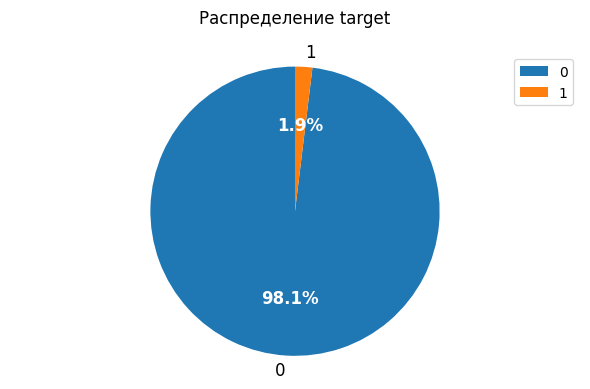

In [94]:
plot_pie_chart(data, 'target', 
               'Распределение target\n')

**Комментарий:** наблюдается сильный дисбаланс классов - только 1,9% клиентов (961 из 49 849) совершили покупку в целевом периоде, тогда как 98,1% (48 888) не являются целевыми. Это критически важная информация для моделирования — потребуется применение методов борьбы с дисбалансом (взвешивание классов, использование метрики ROC-AUC).

3.2 Анализ покупательского поведения

In [95]:
purchase_features = ['cost', 'quantity', 'price', 'unique_purchase_days']

In [96]:
data.groupby('target')[purchase_features].describe()

cost                                                         \
          count         mean          std  min     25%     50%     75%   
target                                                                   
0       48888.0  3277.532012  4294.422765  0.0  1169.0  2099.0  3997.0   
1         961.0  4349.679501  7615.751142  2.0  1095.0  2445.0  4962.0   

                 quantity                                                 \
             max    count      mean       std  min  25%  50%  75%    max   
target                                                                     
0       297954.0  48888.0  2.516466  2.791347  0.0  1.0  2.0  3.0  159.0   
1       122772.0    961.0  4.183143  5.862466  1.0  1.0  2.0  5.0   75.0   

          price                                                        \
          count         mean          std  min    25%     50%     75%   
target                                                                  
0       48888.0  1523.585187  1394.675564  0.0  699.0  1299.0  1999.0   
1         961.0  1219.526951  1124.792194  1.0  524.5   999.0  1632.7   

                unique_purchase_days                                          \
            max                count      mean       std  min  25%  50%  75%   
target                                                                         
0       53499.0              48888.0  1.197492  0.629983  0.0  1.0  1.0  1.0   
1       16989.5                961.0  1.729448  1.588912  1.0  1.0  1.0  2.0   

              
         max  
target        
0       41.0  
1       23.0

Визуализация распределений:

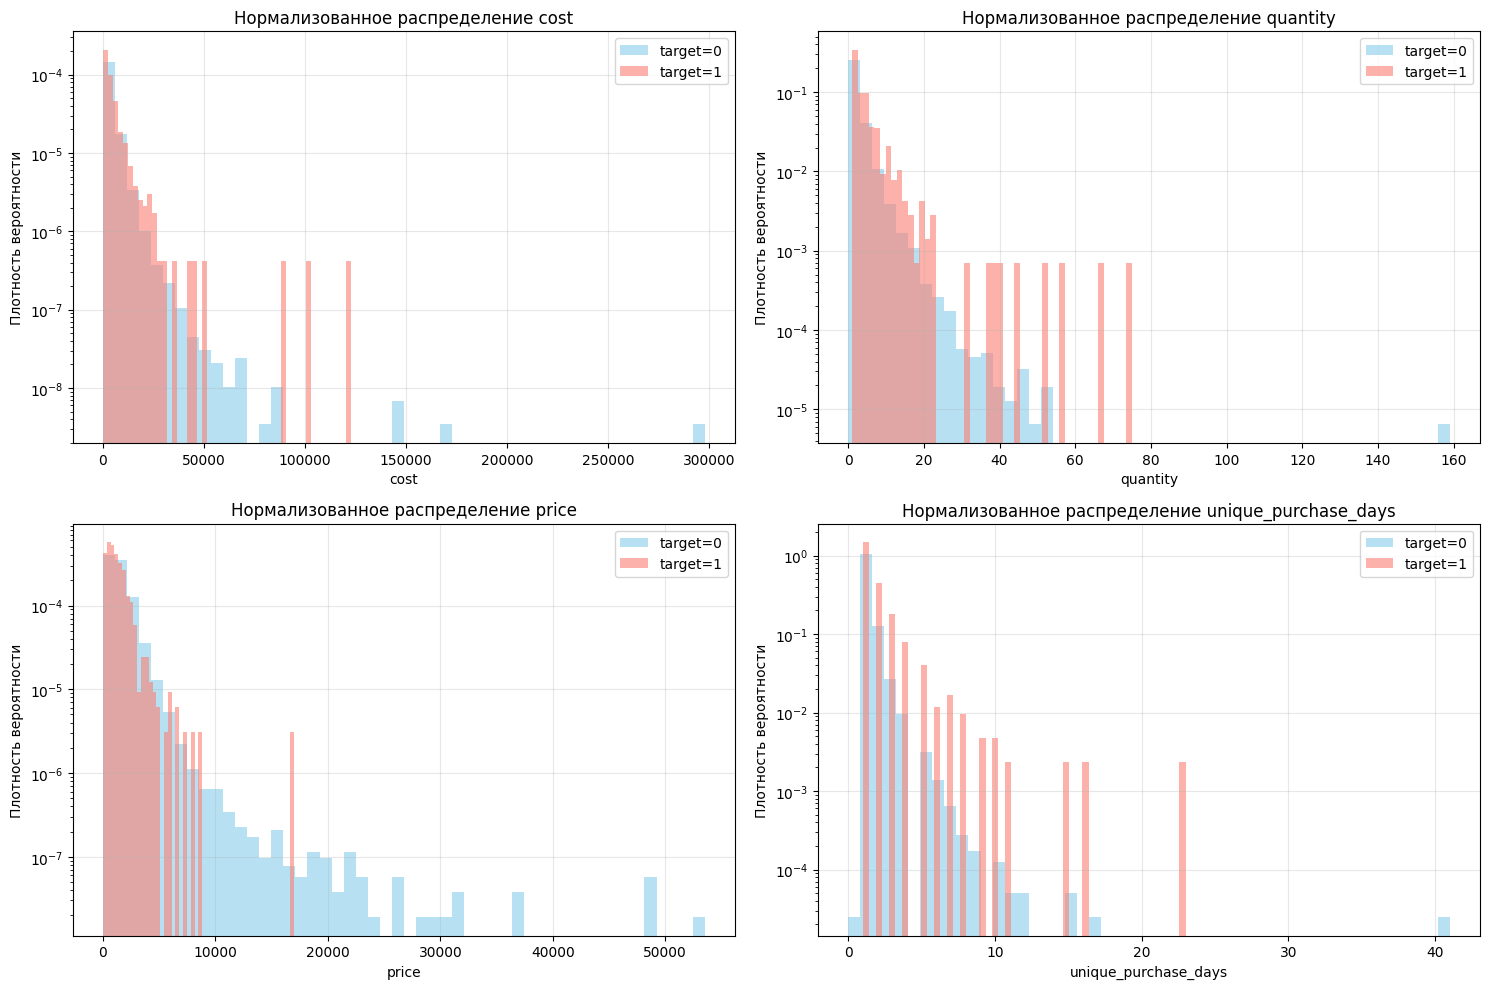

In [97]:
# Создаем сетку 2x2 для 4 графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(purchase_features):
    for target_val, color, label in [(0, 'skyblue', 'target=0'), (1, 'salmon', 'target=1')]:
        # Нормализуем гистограмму (density=True)
        data[data['target'] == target_val][feature].hist(ax=axes[i], 
                                                          alpha=0.6, 
                                                          color=color, 
                                                          label=label, 
                                                          bins=50,
                                                          density=True)  # нормализация
    axes[i].set_title(f'Нормализованное распределение {feature}', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Плотность вероятности', fontsize=10)
    axes[i].legend()
    axes[i].set_yscale('log')  # логарифмическая шкала для лучшей визуализации
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Комментарий:** распределения всех четырех метрик (cost, quantity, price, unique_purchase_days) имеют ярко выраженную степенную зависимость (логарифмическая шкала по оси Y), что указывает на наличие небольшой группы "суперактивных" клиентов с экстремально высокими показателями на фоне основной массы покупателей. При этом клиенты с target=1 устойчиво демонстрируют более "тяжелые хвосты" распределений, особенно заметные в метриках cost и quantity, что логично — будущие покупатели исторически тратили больше и покупали чаще. Визуально видно, что нормальное распределение показателей отсутствует.

3.3 Анализ категорий товаров

In [98]:
category_cols = [col for col in data.columns if col.startswith('category_id_') and col.endswith('_count')]

In [99]:
category_cols

['category_id_4_count',
 'category_id_2_count',
 'category_id_5562_count',
 'category_id_1_count',
 'category_id_5963_count',
 'category_id_3_count',
 'category_id_6060_count',
 'category_id_5_count']

Среднее количество покупок по категориям для каждой группы:

In [100]:
category_means = data.groupby('target')[category_cols].mean().T
category_means.columns = ['target=0', 'target=1']
category_means['diff'] = category_means['target=1'] - category_means['target=0']
category_means = category_means.sort_values('diff', ascending=False)

print("Среднее количество покупок по категориям:")
print(category_means)

Среднее количество покупок по категориям:
                        target=0  target=1      diff
category_id_4_count     1.452074  2.537981  1.085907
category_id_5562_count  0.577074  0.973985  0.396911
category_id_6060_count  0.087752  0.174818  0.087066
category_id_2_count     0.359536  0.434964  0.075427
category_id_5963_count  0.015730  0.020812  0.005082
category_id_5_count     0.000020  0.000000 -0.000020
category_id_1_count     0.000061  0.000000 -0.000061
category_id_3_count     0.000123  0.000000 -0.000123


Визуализация:

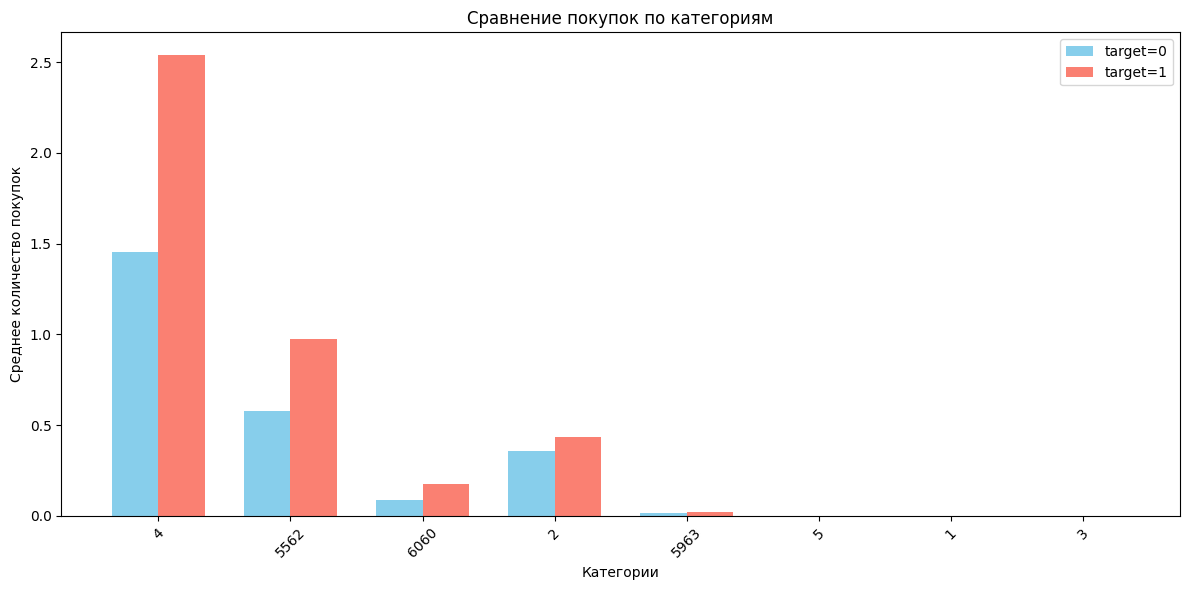

In [101]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(category_means))
width = 0.35

ax.bar([i - width/2 for i in x], category_means['target=0'], width, label='target=0', color='skyblue')
ax.bar([i + width/2 for i in x], category_means['target=1'], width, label='target=1', color='salmon')

ax.set_xlabel('Категории')
ax.set_ylabel('Среднее количество покупок')
ax.set_title('Сравнение покупок по категориям')
ax.set_xticks(x)
ax.set_xticklabels([col.replace('category_id_', '').replace('_count', '') for col in category_means.index], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

**Комментарий:** Наибольшие различия между группами наблюдаются в категориях 4 (почти в 2 раза больше покупок у target=1) и 5562 (почти в 2 раза больше), что делает их потенциально важными предикторами целевого события. Категории 1, 3 и 5 практически не покупаются клиентами из обеих групп (средние значения близки к нулю) и, вероятно, не будут информативны для модели.

3.4 Анализ вовлеченности в рассылки

In [102]:
message_features = ['unique_messages', 'unique_bulk_campaign', 'event_send', 'event_open', 
                    'event_click', 'event_purchase', 'channel_email', 
                    'channel_mobile_push']

Статистика для клиентов с рассылками:

In [103]:
clients_with_messages = data[data['has_bulk_campaign'] == 1]

print("Статистика вовлеченности (только клиенты с рассылками):")
clients_with_messages.groupby('target')[message_features].describe()

Статистика вовлеченности (только клиенты с рассылками):


unique_messages                                                \
                 count      mean       std  min  25%  50%  75%   max   
target                                                                 
0              41136.0  1.170994  0.554532  0.0  1.0  1.0  1.0  17.0   
1                846.0  1.625296  1.313660  1.0  1.0  1.0  2.0  15.0   

       unique_bulk_campaign                                              \
                      count        mean         std  min     25%    50%   
target                                                                    
0                   41136.0  185.831316  103.325341  1.0  114.00  173.0   
1                     846.0  208.309693  110.632698  1.0  131.25  208.0   

                      event_send                                             \
          75%     max      count        mean         std  min    25%    50%   
target                                                                        
0       256.0  2465.0    41136.0  187.689323  104.447830  0.0  115.0  174.5   
1       276.0  1273.0      846.0  210.648936  111.776863  1.0  132.0  210.0   

                      event_open                                         \
          75%     max      count       mean        std  min   25%   50%   
target                                                                    
0       259.0  2473.0    41136.0  58.567046  72.638177  0.0   4.0  25.0   
1       278.0  1277.0      846.0  89.934988  99.111027  0.0  13.0  59.0   

                      event_click                                              \
          75%     max       count       mean        std  min  25%   50%   75%   
target                                                                          
0        93.0   688.0     41136.0  10.409374  13.433924  0.0  3.0   6.0  13.0   
1       147.0  1268.0       846.0  18.640662  24.364849  0.0  6.0  11.0  23.0   

              event_purchase                                                \
          max          count      mean       std  min  25%  50%  75%   max   
target                                                                       
0       380.0        41136.0  1.314275  1.277238  0.0  1.0  1.0  1.0  81.0   
1       258.0          846.0  1.938534  2.385063  0.0  1.0  1.0  2.0  36.0   

       channel_email                                                          \
               count        mean         std  min   25%    50%    75%    max   
target                                                                         
0            41136.0  114.931228   92.361479  0.0  13.0  122.0  184.0  870.0   
1              846.0  115.008274  103.671049  0.0   0.0  114.0  189.0  580.0   

       channel_mobile_push                                                     \
                     count        mean         std  min    25%    50%     75%   
target                                                                          
0                  41136.0  143.747204  144.178901  0.0   0.00  120.0  240.00   
1                    846.0  206.742317  186.918474  0.0  22.25  198.5  303.75   

                
           max  
target          
0       2267.0  
1       2294.0

Доля клиентов с рассылками по группам:

In [104]:
message_coverage = pd.crosstab(data['target'], data['has_bulk_campaign'], normalize='index') * 100
print("\nДоля клиентов с рассылками по группам:")
message_coverage


Доля клиентов с рассылками по группам:


has_bulk_campaign,0,1
target,,
0,15.856652,84.143348
1,11.966701,88.033299


Визуализация:

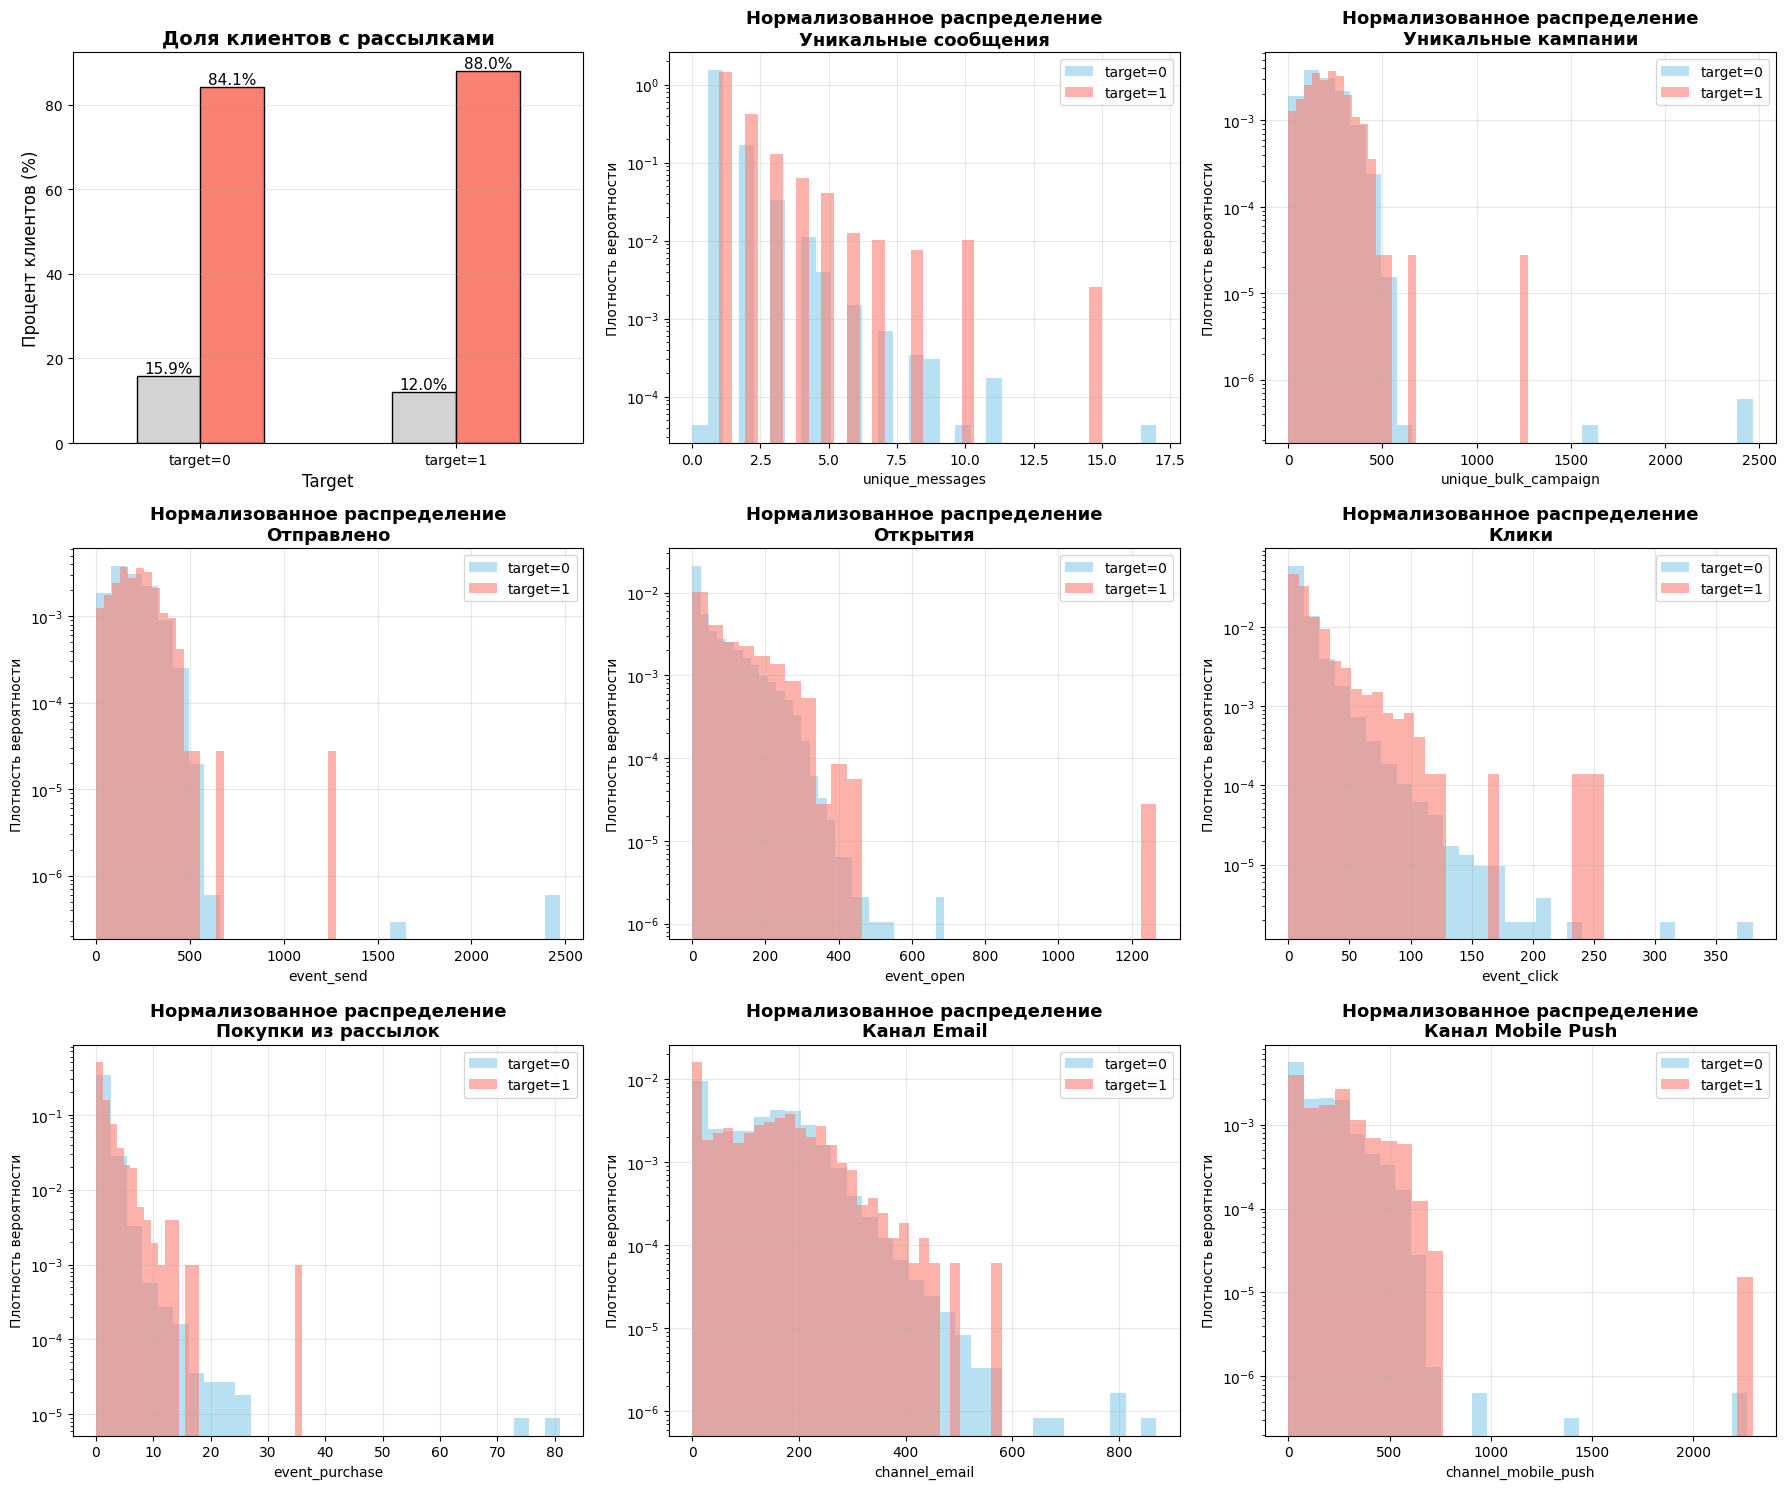

In [105]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Список метрик для визуализации (8 метрик + 1 график для долей)
metrics_to_plot = ['unique_messages', 'unique_bulk_campaign', 'event_send', 
                   'event_open', 'event_click', 'event_purchase', 
                   'channel_email', 'channel_mobile_push']
titles = ['Уникальные сообщения', 'Уникальные кампании', 'Отправлено', 
          'Открытия', 'Клики', 'Покупки из рассылок', 
          'Канал Email', 'Канал Mobile Push']

# График 1: Доля клиентов с рассылками (первый подграфик)
ax = axes[0]
message_coverage.plot(kind='bar', ax=ax, color=['lightgray', 'salmon'], edgecolor='black', legend=False)
ax.set_title('Доля клиентов с рассылками', fontsize=14, fontweight='bold')
ax.set_xlabel('Target', fontsize=12)
ax.set_ylabel('Процент клиентов (%)', fontsize=12)
ax.set_xticklabels(['target=0', 'target=1'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=11)

# Графики 2-9: НОРМАЛИЗОВАННЫЕ распределения метрик (для клиентов с рассылками)
for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[i+1]  # начинаем со второго подграфика
    for target_val, color, label in [(0, 'skyblue', 'target=0'), (1, 'salmon', 'target=1')]:
        subset = clients_with_messages[clients_with_messages['target'] == target_val]
        if len(subset) > 0:
            subset[metric].hist(ax=ax, alpha=0.6, color=color, label=label, 
                               bins=30, density=True)  # density=True для нормализации
    ax.set_title(f'Нормализованное распределение\n{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel(metric, fontsize=10)
    ax.set_ylabel('Плотность вероятности', fontsize=10)
    ax.legend()
    ax.set_yscale('log')  # логарифмическая шкала для лучшей визуализации
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Комментарий:** клиенты с target=1 демонстрируют значительно более высокую вовлеченность во все типы рассылок: 88% из них имеют историю взаимодействия (против 84% в группе target=0), а средние показатели по всем метрикам (unique_messages, event_send, event_open, event_click) в 1,5–2 раза выше. Особенно заметно различие в мобильном канале — клиенты с целевым событием получают почти вдвое больше push-уведомлений, что может указывать на эффективность этого канала для стимулирования покупок.

3.5 Анализ конверсионных метрик

In [106]:
conv_features = ['conv_open_to_click', 'conv_click_to_purchase', 
                 'conv_open_to_purchase', 'conv_send_to_open']

# Статистика по конверсиям
print("Статистика конверсий по группам:")
data.groupby('target')[conv_features].describe()

Статистика конверсий по группам:


conv_open_to_click                                                    \
                    count      mean       std  min  25%       50%       75%   
target                                                                        
0                 48888.0  0.381006  1.316477  0.0  0.0  0.066667  0.394737   
1                   961.0  0.544655  3.225400  0.0  0.0  0.090909  0.367347   

             conv_click_to_purchase                                     \
         max                  count      mean       std  min       25%   
target                                                                   
0       72.0                48888.0  0.240486  0.388470  0.0  0.011462   
1       69.0                  961.0  0.172060  0.260943  0.0  0.023256   

                                 conv_open_to_purchase                      \
             50%       75%   max                 count      mean       std   
target                                                                       
0       0.111111  0.307692  25.0               48888.0  0.074793  0.253655   
1       0.090909  0.200000   3.0                 961.0  0.090360  0.759886   

                                           conv_send_to_open            \
        min  25%       50%       75%   max             count      mean   
target                                                                   
0       0.0  0.0  0.009709  0.050000  25.0           48888.0  0.262470   
1       0.0  0.0  0.010101  0.035714  16.0             961.0  0.392654   

                                                          
             std  min       25%       50%       75%  max  
target                                                    
0       0.326807  0.0  0.000000  0.117229  0.455388  9.0  
1       0.391612  0.0  0.007937  0.290323  0.706294  3.0

Визуализация:

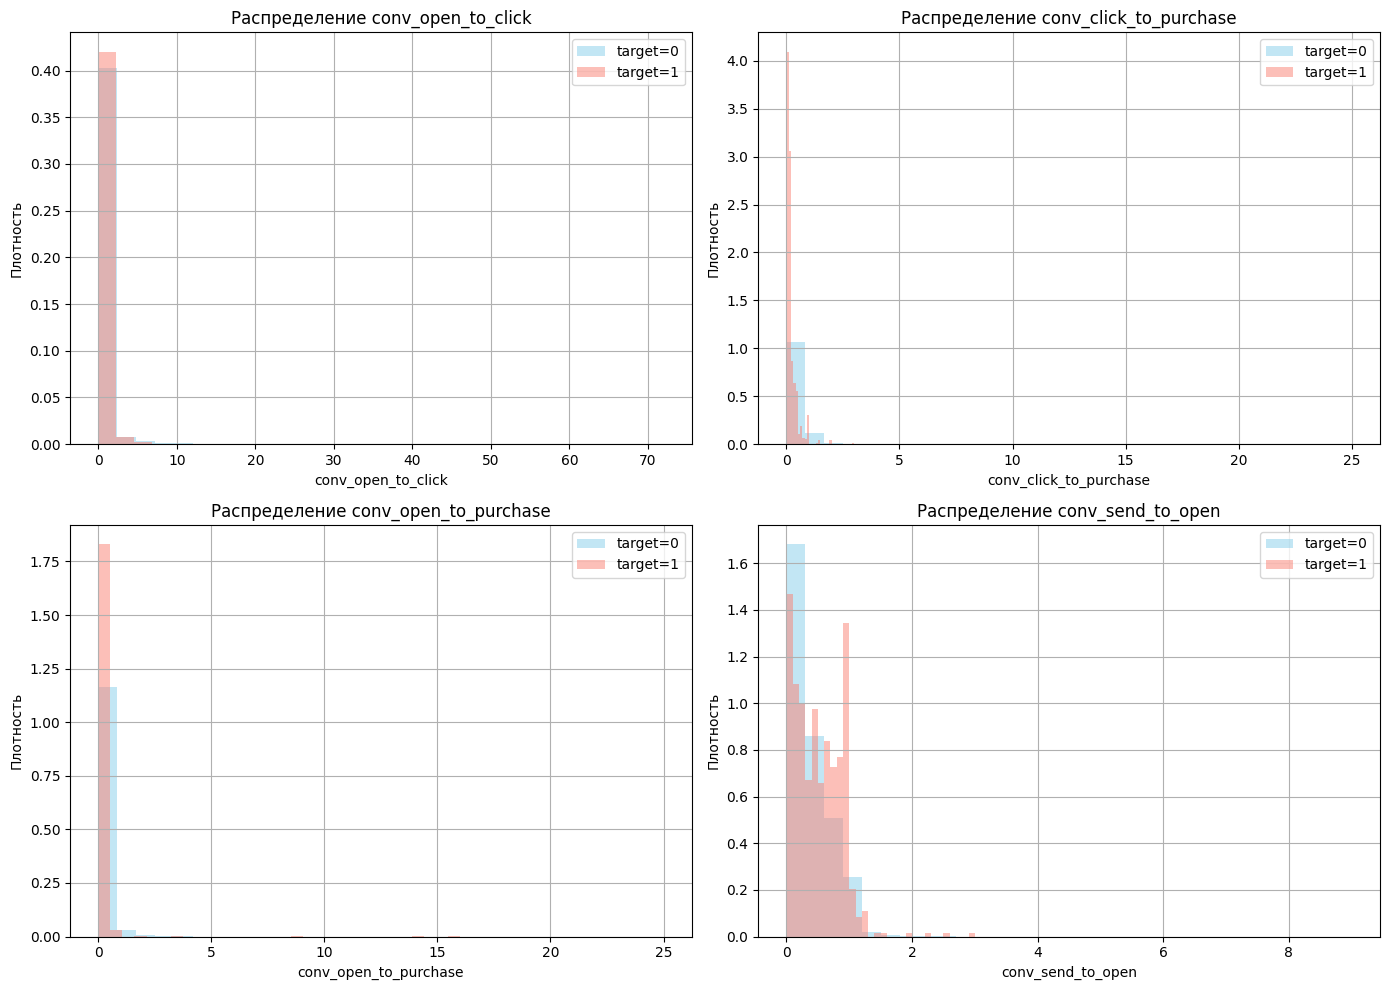

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(conv_features):
    for target_val, color, label in [(0, 'skyblue', 'target=0'), (1, 'salmon', 'target=1')]:
        subset = data[data['target'] == target_val]
        # Убираем нулевые значения для лучшей визуализации
        subset = subset[subset[feature] > 0]
        if len(subset) > 0:
            subset[feature].hist(ax=axes[i], alpha=0.5, color=color, label=label, bins=30, density=True)
    axes[i].set_title(f'Распределение {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Плотность')
    axes[i].legend()

plt.tight_layout()
plt.show()

**Комментарий:** Конверсионные метрики демонстрируют схожие паттерны для обеих групп, но с важными различиями. Наиболее показательной является метрика conv_send_to_open (конверсия из отправки в открытие): у клиентов с target=1 среднее значение (0,39) значительно выше, чем в группе target=0 (0,26), что указывает на их большую склонность взаимодействовать с полученными рассылками. Во всех распределениях наблюдается высокая концентрация значений вблизи нуля с длинными "хвостами", что говорит о наличии небольшой группы суперактивных клиентов. Согласно визуальному анализу - нормальное распределения показателей отсутствует.

3.6 Корреляционный анализ

Используем библиотеку phik для подсчёта корреляции между признаками разных типов данных:

In [108]:
interval_cols = ['cost', 'price', 'conv_open_to_click', 'conv_click_to_purchase', 'conv_open_to_purchase', 'conv_send_to_open']
phik_overview = data.phik_matrix(interval_cols=interval_cols)
phik_overview

,target,cost,quantity,price,category_id_4_count,category_id_2_count,category_id_5562_count,category_id_1_count,category_id_5963_count,category_id_3_count,category_id_6060_count,category_id_5_count,unique_purchase_days,unique_messages,unique_bulk_campaign,event_click,event_close,event_complain,event_hard_bounce,event_hbq_spam,event_open,event_purchase,event_send,event_soft_bounce,event_subscribe,event_unsubscribe,channel_email,channel_mobile_push,conv_open_to_click,conv_click_to_purchase,conv_open_to_purchase,conv_send_to_open,has_bulk_campaign
target,1.000000,0.044763,0.136788,0.000000,0.124437,0.015353,0.053868,0.000000,0.008405,0.000000,0.030747,0.000000,0.151196,0.140790,0.091256,0.150942,0.000000,0.000000,0.034795,0.000000,0.153025,0.099943,0.091515,0.000000,0.013433,0.014898,0.103393,0.168036,0.026002,0.000000,0.050700,0.045762,0.021614
cost,0.044763,1.000000,0.803898,0.457809,0.787318,0.524051,0.331366,0.000000,0.097374,0.000000,0.547433,0.000000,0.588520,0.644599,0.000000,0.182705,0.000000,0.000000,0.000000,0.000000,0.000000,0.400471,0.000000,0.000000,0.000000,0.000000,0.000000,0.057421,0.000000,0.061874,0.098678,0.000000,0.000000
quantity,0.136788,0.803898,1.000000,0.000000,0.973715,0.806528,0.957655,0.415603,0.503790,0.054182,0.779050,0.087310,0.949701,0.928068,0.297500,0.767884,0.000000,0.000000,0.055695,0.000000,0.429646,0.902231,0.268473,0.000000,0.477134,0.252977,0.678229,0.470492,0.213026,0.793755,0.373715,0.000000,0.011704
price,0.000000,0.457809,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.042157,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.065450,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012695
category_id_4_count,0.124437,0.787318,0.973715,0.000000,1.000000,0.701383,0.542626,0.102826,0.558195,0.000000,0.685432,0.000000,0.861869,0.863019,0.000000,0.640930,0.000000,0.000000,0.000000,0.000000,0.317505,0.725714,0.000000,0.000000,0.669664,0.367146,0.543897,0.000000,0.160321,0.074493,0.275421,0.000000,0.017864
category_id_2_count,0.015353,0.524051,0.806528,0.000000,0.701383,1.000000,0.242500,0.047902,0.000000,0.000000,0.634751,0.000000,0.685763,0.675217,0.000000,0.340847,0.000000,0.000000,0.203408,0.000000,0.000000,0.455381,0.000000,0.000000,0.000000,0.035051,0.000000,0.000000,0.000000,0.053656,0.000000,0.000000,0.025704
category_id_5562_count,0.053868,0.331366,0.957655,0.000000,0.542626,0.242500,1.000000,0.672911,0.171905,0.077532,0.207067,0.126327,0.625080,0.561747,0.263886,0.711084,0.000000,0.000000,0.000000,0.000000,0.223258,0.775441,0.277843,0.000000,0.000000,0.000000,0.442995,0.405565,0.123870,0.780410,0.297175,0.000000,0.039662
category_id_1_count,0.000000,0.000000,0.415603,0.000000,0.102826,0.047902,0.672911,1.000000,0.000000,0.000000,0.000000,0.000000,0.275961,0.238610,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030943,0.472724,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
category_id_5963_count,0.008405,0.097374,0.503790,0.042157,0.558195,0.000000,0.171905,0.000000,1.000000,0.000000,0.190992,0.000000,0.076823,0.082093,0.000000,0.000000,0.000000,0.000000,0.009310,0.000000,0.120098,0.161317,0.000000,0.000000,0.000000,0.000000,0.000000,0.088149,0.000000,0.074185,0.000000,0.000000,0.008518
category_id_3_count,0.000000,0.000000,0.054182,0.000000,0.000000,0.000000,0.077532,0.000000,0.000000,1.000000,0.024759,0.000000,0.035869,0.015716,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.057008,0.056887,0.000000,0.000000,0.000000,0.000000,0.000000,0.134051,0.000000,0.029281,0.000000,0.000000,0.000000


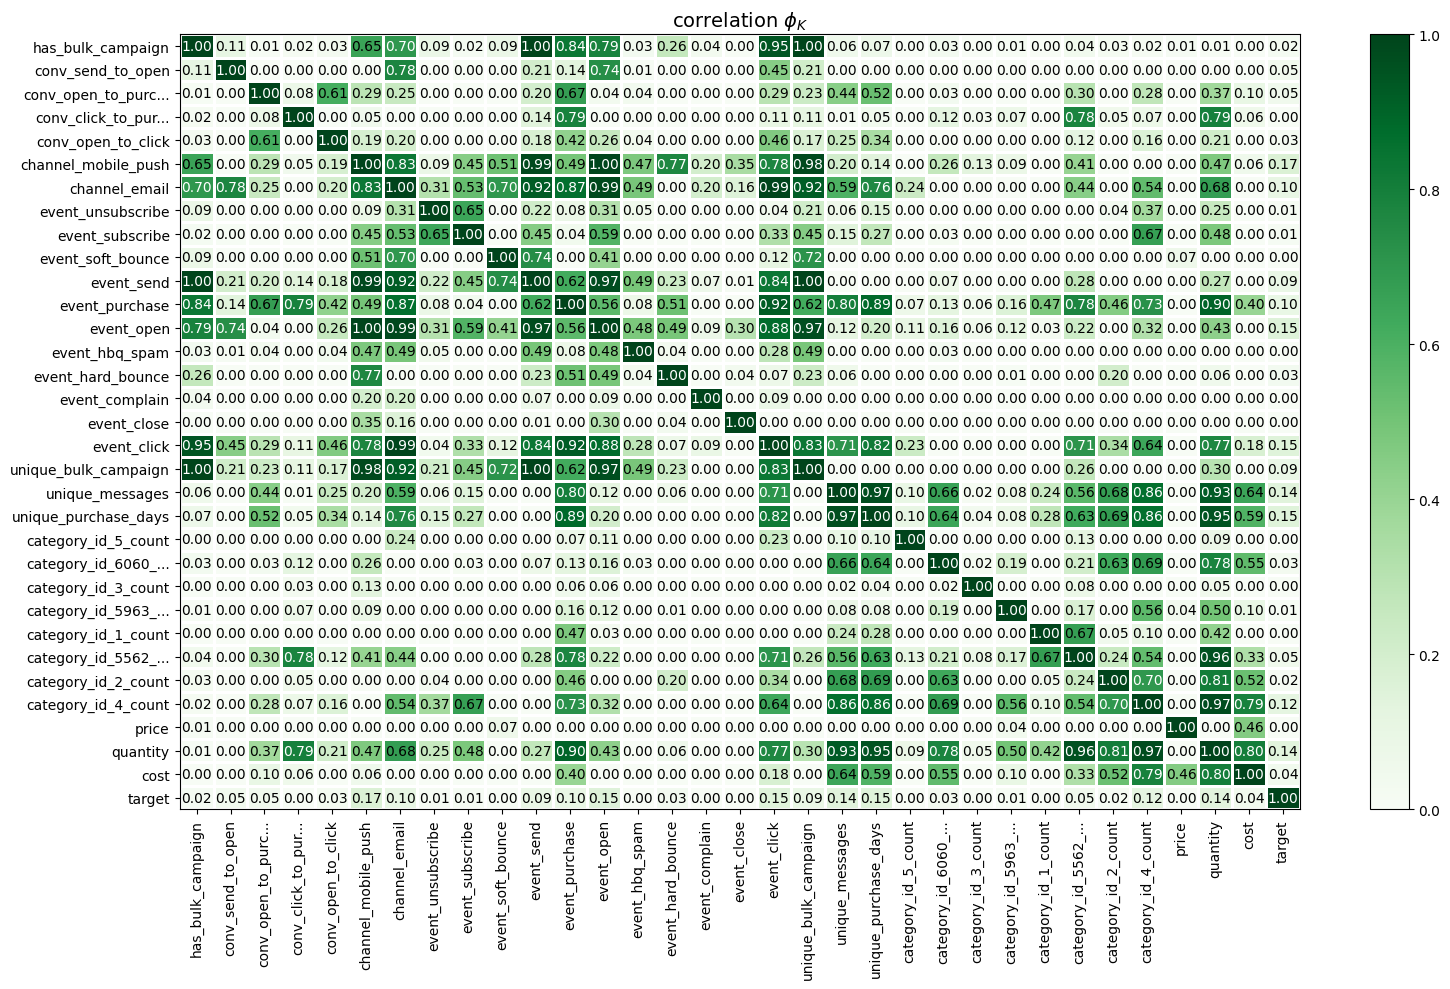

In [109]:
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1,
    figsize=(16, 10)
)

**Комментарий:**

Анализ phik-корреляций выявил несколько групп признаков с критически высокой корреляцией (>0,9), что указывает на потенциальную проблему мультиколлинеарности:

Пары признаков с корреляцией выше 0,9:

- unique_purchase_days и unique_messages (0,97)
- event_send и unique_bulk_campaign (>0,99)
- event_send и has_bulk_campaign (>0,99)
- event_open и channel_email (0,99)
- event_open и channel_mobile_push (0,99)
- quantity и category_id_4_count (0,97)
- quantity и category_id_5562_count (0,96)
- quantity и unique_purchase_days (0,95)
- event_click и channel_email (0,99)
- unique_bulk_campaign и has_bulk_campaign (1,0)

При этом показатель target имеет низкую взаимосвязь с объясняющими показателями - корреляция не превышает 0,17, что типично для задач с бинарной классификацией и большим количеством шума.

План действий:

- Среди дублирующихся показателей оставить наиболее интерпретируемые:

    - Удалить: event_send, event_open, unique_messages, has_bulk_campaign
    - Оставить: unique_bulk_campaign, channel_email, channel_mobile_push, unique_purchase_days
- Категорийные счетчики (category_id_*_count) оставить, так как они несут разную смысловую нагрузку
- В дальнейшем использовать класс моделей, устойчивых к мультиколлинеарности (градиентный бустинг, случайный лес), чтобы не терять потенциально важную информацию

# Шаг 4. Подготовка данных

4.1 Определение признаков для моделирования

In [110]:
# Целевая переменная
target = 'target'

# Признаки, которые удаляем согласно плану
cols_to_drop = [
    'event_send',           # дублирует unique_bulk_campaign
    'event_open',           # дублирует channel_*
    'unique_messages',      # дублирует unique_purchase_days
    'has_bulk_campaign'     # дублирует unique_bulk_campaign
]

# Все колонки датафрейма
all_cols = data.columns.tolist()

# Признаки для модели (все, кроме target и удаляемых)
features = [col for col in all_cols if col != target and col not in cols_to_drop]

print(f"Всего признаков до удаления: {len(all_cols) - 1}")
print(f"Удаляем признаков: {len(cols_to_drop)}")
print(f"Признаков для модели: {len(features)}")
print(f"\nСписок признаков для модели:\n{features}")

Всего признаков до удаления: 32
Удаляем признаков: 4
Признаков для модели: 28

Список признаков для модели:
['cost', 'quantity', 'price', 'category_id_4_count', 'category_id_2_count', 'category_id_5562_count', 'category_id_1_count', 'category_id_5963_count', 'category_id_3_count', 'category_id_6060_count', 'category_id_5_count', 'unique_purchase_days', 'unique_bulk_campaign', 'event_click', 'event_close', 'event_complain', 'event_hard_bounce', 'event_hbq_spam', 'event_purchase', 'event_soft_bounce', 'event_subscribe', 'event_unsubscribe', 'channel_email', 'channel_mobile_push', 'conv_open_to_click', 'conv_click_to_purchase', 'conv_open_to_purchase', 'conv_send_to_open']


4.2 Создание матрицы признаков X и целевой переменной y

In [111]:
X = data[features].copy()
y = data[target].copy()

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Распределение y:\n{y.value_counts(normalize=True)}")

Размер X: (49849, 28)
Размер y: (49849,)
Распределение y:
target
0    0.980722
1    0.019278
Name: proportion, dtype: float64


4.3 Разделение на train/test с сохранением стратификации

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25,           # 25% на тест
    random_state=RANDOM_STATE,
    stratify=y,              # сохраняем пропорцию классов
    shuffle=True
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение target в train:\n{y_train.value_counts(normalize=True)}")
print(f"\nРаспределение target в test:\n{y_test.value_counts(normalize=True)}")

Размер обучающей выборки: (37386, 28)
Размер тестовой выборки: (12463, 28)

Распределение target в train:
target
0    0.980715
1    0.019285
Name: proportion, dtype: float64

Распределение target в test:
target
0    0.980743
1    0.019257
Name: proportion, dtype: float64


4.4 Создание пайплайна предобработки

- Определяем количественные признаки для масштабирования (все числовые признаки, кроме бинарных и счетчиков)

In [113]:
quantitative_features = ['cost', 'price', 'conv_open_to_click', 'conv_click_to_purchase', 'conv_open_to_purchase', 'conv_send_to_open']
print(f"Количественные признаки для масштабирования: {quantitative_features}")

Количественные признаки для масштабирования: ['cost', 'price', 'conv_open_to_click', 'conv_click_to_purchase', 'conv_open_to_purchase', 'conv_send_to_open']


- Остальные признаки (целочисленные счетчики, бинарные и т.д.)

In [114]:
other_features = [col for col in X.columns if col not in quantitative_features]
print(f"Остальные признаки (без масштабирования): {len(other_features)}")

Остальные признаки (без масштабирования): 22


- Общий пайплайн для подготовки данных:

In [115]:
data_preprocessor = ColumnTransformer(
    [('quant', StandardScaler(), quantitative_features)],
    remainder='passthrough'
)

- Проверим работу пайплайна:

In [116]:
try:
    # Фитируем и трансформируем тренировочные данные
    X_train_preprocessed = data_preprocessor.fit_transform(X_train)
    
    # Трансформируем тестовые данные
    X_test_preprocessed = data_preprocessor.transform(X_test)
    
    print('Пайплайн успешно работает!')
    print(f'Размерность X_train после preprocessing: {X_train_preprocessed.shape}')
    print(f'Размерность X_test после preprocessing: {X_test_preprocessed.shape}')

except Exception as e:
    print(f'Ошибка в пайплайне: {e}')

Пайплайн успешно работает!
Размерность X_train после preprocessing: (37386, 28)
Размерность X_test после preprocessing: (12463, 28)


**Общие выводы по шагу 4:**

Отбор признаков:

- Удалено 4 признака с высокой мультиколлинеарностью (event_send, event_open, unique_messages, has_bulk_campaign)
- Для моделирования отобрано 28 признаков

Целевая переменная:

- Сильный дисбаланс классов: 1,93% положительных примеров (target=1)
- Это будет учтено при выборе метрик и настройке моделей

Разделение данных:

- Train: 37 386 строк (75%)
- Test: 12 463 строки (25%)
- Стратификация сработала — пропорции классов в train и test совпадают с исходными

Предобработка:

- Количественные признаки (6): cost, price, 4 конверсионные метрики — будут масштабироваться через StandardScaler (по умолчанию)
- Остальные признаки (22) — передаются без изменений
- Пайплайн успешно протестирован на train/test данных

Итоговая структура данных для моделирования:

- X_train: 37 386 × 28 признаков
- X_test: 12 463 × 28 признаков
- y_train/y_test: сбалансированы по стратификации

Данные полностью готовы к следующему шагу — обучению моделей!

# Шаг 5. Обучение моделей

5.1 Создание итогового пайплайна

In [117]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))  # заглушка
])

5.2 Определение пространства гиперпараметров

In [118]:
param_grid = [  
    # Случайный лес
    {
        'classifier': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'classifier__n_estimators': [50, 100, 200, 300],
        'classifier__max_depth': [None, 5, 10, 15, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2', None],
        'classifier__class_weight': ['balanced', 'balanced_subsample', None],
        'preprocessor__quant': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
    
    # Градиентный бустинг (XGBoost)
    {
        'classifier': [XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 7, 9],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        # Для дисбаланса классов
        'classifier__scale_pos_weight': [1, 2, 3, 5, 10, 
                                         (y_train == 0).sum() / (y_train == 1).sum()],  # авторасчет
        'preprocessor__quant': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
    
    # CatBoost
    {
        'classifier': [CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)],
        'classifier__iterations': [100, 200, 300],
        'classifier__depth': [4, 6, 8, 10],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__l2_leaf_reg': [1, 3, 5, 7],
        'classifier__auto_class_weights': ['Balanced', 'SqrtBalanced'],
        'preprocessor__quant': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]

print(f'Определено {len(param_grid)} групп моделей для поиска гиперпараметров')

Определено 3 групп моделей для поиска гиперпараметров


5.3 Настройка и запуск поиска гиперпараметров

In [119]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=5,                          
    scoring='roc_auc',             
    random_state=RANDOM_STATE,
    n_jobs=-1,                     
    n_iter=100,
    verbose=1,
    error_score='raise'             # показывать ошибки, если они возникнут
)

Обучаем модели с поиском гиперпараметров:

In [120]:
randomized_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'classifier': [RandomForestC...ndom_state=42)], 'classifier__class_weight': ['balanced', 'balanced_subsample', ...], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2', ...], ...}, {'classifier': [XGBClassifier...ree=None, ...)], 'classifier__colsample_bytree': [0.6, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binar

5.4 Анализ результатов поиска

In [121]:
best_model = randomized_search.best_estimator_
best_model_name = type(best_model.named_steps['classifier']).__name__

print(f'Лучшая модель: {best_model_name}')
print(f'\nЛучшие гиперпараметры:')
for param, value in randomized_search.best_params_.items():
    print(f'   {param}: {value}')

# Лучшая метрика на кросс-валидации
print(f'\nЛучший ROC-AUC на кросс-валидации: {randomized_search.best_score_:.4f}')

Лучшая модель: XGBClassifier

Лучшие гиперпараметры:
   preprocessor__quant: RobustScaler()
   classifier__subsample: 0.8
   classifier__scale_pos_weight: 2
   classifier__n_estimators: 50
   classifier__max_depth: 3
   classifier__learning_rate: 0.1
   classifier__colsample_bytree: 0.6
   classifier: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strateg

Предсказания на тестовой выборке:

In [122]:
y_pred_proba = randomized_search.predict_proba(X_test)[:, 1]
y_pred = randomized_search.predict(X_test)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC на тестовой выборке: {test_roc_auc:.4f}")

ROC-AUC на тестовой выборке: 0.7405


5.5 Матрица ошибок:

In [123]:
confusion = np.zeros((2, 2)).astype(np.int64)
for i in range(2):
   for j in range(2):
            confusion[i][j] = np.sum(np.logical_and(y_test == i, y_pred == j))

# выведем результат на экран
print(confusion)

[[12221     2]
 [  240     0]]


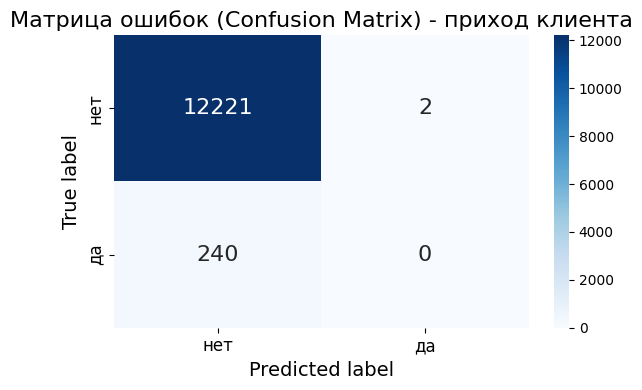

In [124]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=True,
            xticklabels=['нет', 'да'],
            yticklabels=['нет', 'да'],
            annot_kws={'size': 16})

plt.title('Матрица ошибок (Confusion Matrix) - приход клиента', fontsize=16)
plt.xlabel('Predicted label', fontsize=14)
plt.ylabel('True label', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

5.6 Оценим важность признаков для лучшей модели:

- Permutation importance

Получаем лучшую модель из randomized_search:

In [125]:
best_model = randomized_search.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quant', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Вычисляем permutation importance:

In [126]:
perm_importance = permutation_importance(
    best_model, X_test, y_test,
    scoring='roc_auc',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

Создаем DataFrame с важностью признаков:

In [127]:
perm_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print('Важность признаков по Permutation Importance:')
print(perm_importance_df.round(3))

Важность признаков по Permutation Importance:
                   feature  importance_mean  importance_std
11    unique_purchase_days            0.049           0.006
13             event_click            0.042           0.007
27       conv_send_to_open            0.018           0.003
2                    price            0.017           0.005
23     channel_mobile_push            0.012           0.004
22           channel_email            0.008           0.002
1                 quantity            0.006           0.004
25  conv_click_to_purchase            0.006           0.003
12    unique_bulk_campaign            0.003           0.001
21       event_unsubscribe            0.003           0.002
0                     cost            0.002           0.002
26   conv_open_to_purchase            0.001           0.002
24      conv_open_to_click            0.001           0.001
18          event_purchase            0.000           0.001
4      category_id_2_count            0.000           

Визуализация Permutation Importance:

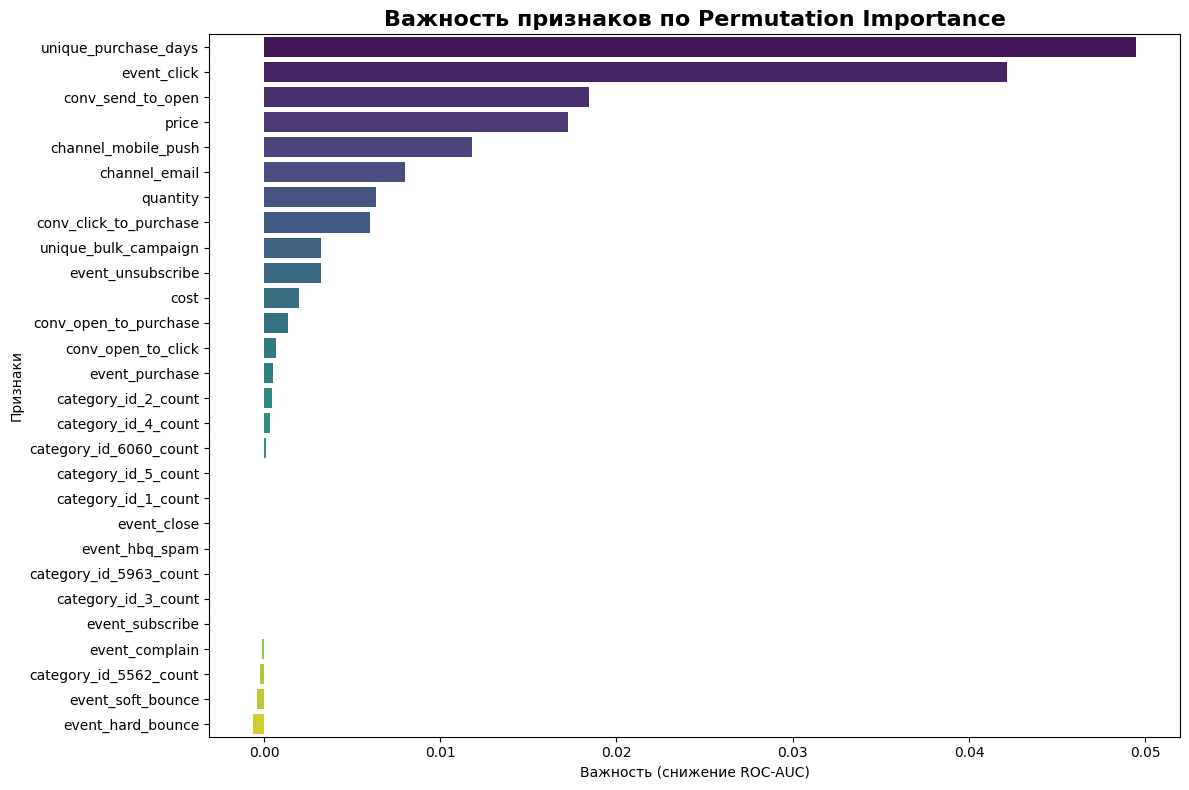

In [128]:
plt.figure(figsize=(12, 8))
top_features = perm_importance_df
sns.barplot(data=top_features, x='importance_mean', y='feature', 
            palette='viridis')
plt.title('Важность признаков по Permutation Importance', fontsize=16, fontweight='bold')
plt.xlabel('Важность (снижение ROC-AUC)')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

**Комментарий:**

С точки зрения Permutation Importance наиболее важные признаки:
- unique_purchase_days
- event_click
- conv_send_to_open
- price
- channel_mobile_push
- channel_email
- quantity
- conv_click_to_purchase

- SHAP

Получаем компоненты лучшей модели:

In [129]:
final_model = best_model.named_steps['classifier']
best_preprocessor = best_model.named_steps['preprocessor']

In [130]:
final_model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [131]:
best_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quant', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{f

Преобразуем тестовые данные с помощью препроцессора:

In [132]:
X_test_processed = best_preprocessor.transform(X_test)

Получаем имена признаков после препроцессинга:

In [133]:
feature_names = (
    quantitative_features + 
    other_features
)
print(f'Размерность обработанных данных: {X_test_processed.shape}')
print(f'Количество признаков: {len(feature_names)}')

Размерность обработанных данных: (12463, 28)
Количество признаков: 28


Вычисление SHAP значений:

In [134]:
explainer = shap.KernelExplainer(final_model.predict_proba, X_test_processed[:100])  # уменьшили background data
shap_values = explainer.shap_values(X_test_processed[:400], nsamples=100)  # уменьшили тестовые данные и samples

print(f'Тип shap_values: {type(shap_values)}')
print(f'Форма shap_values: {np.array(shap_values).shape}')

100%|████████████████████████████████████████| 400/400 [00:01<00:00, 223.11it/s]

Тип shap_values: <class 'numpy.ndarray'>
Форма shap_values: (400, 28, 2)


Для бинарной классификации берем SHAP значения для положительного класса (купил):

In [135]:
shap_values_positive = shap_values[:, :, 1]
print(f'Размерность SHAP значений: {shap_values_positive.shape}')

Размерность SHAP значений: (400, 28)


Визуализация:

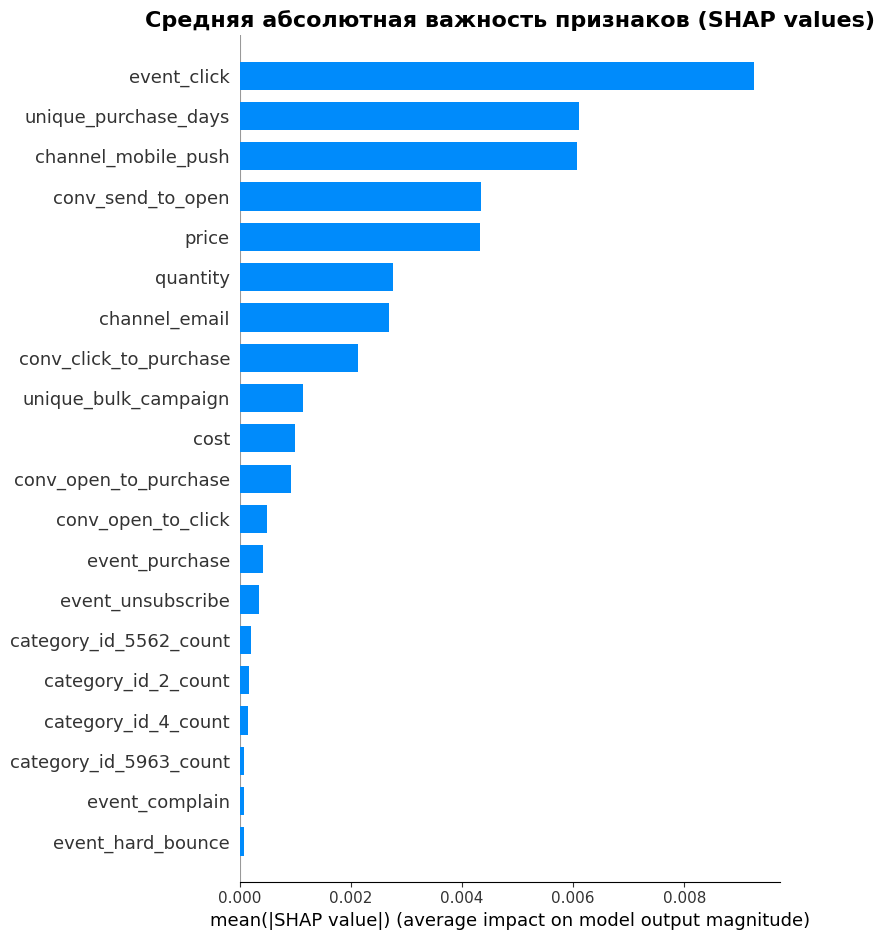

In [136]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_positive, X_test_processed, 
                  feature_names=feature_names, plot_type='bar', show=False)
plt.title('Средняя абсолютная важность признаков (SHAP values)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Комментарий:**

Результаты SHAP в целом схожи с Permutation Importance.

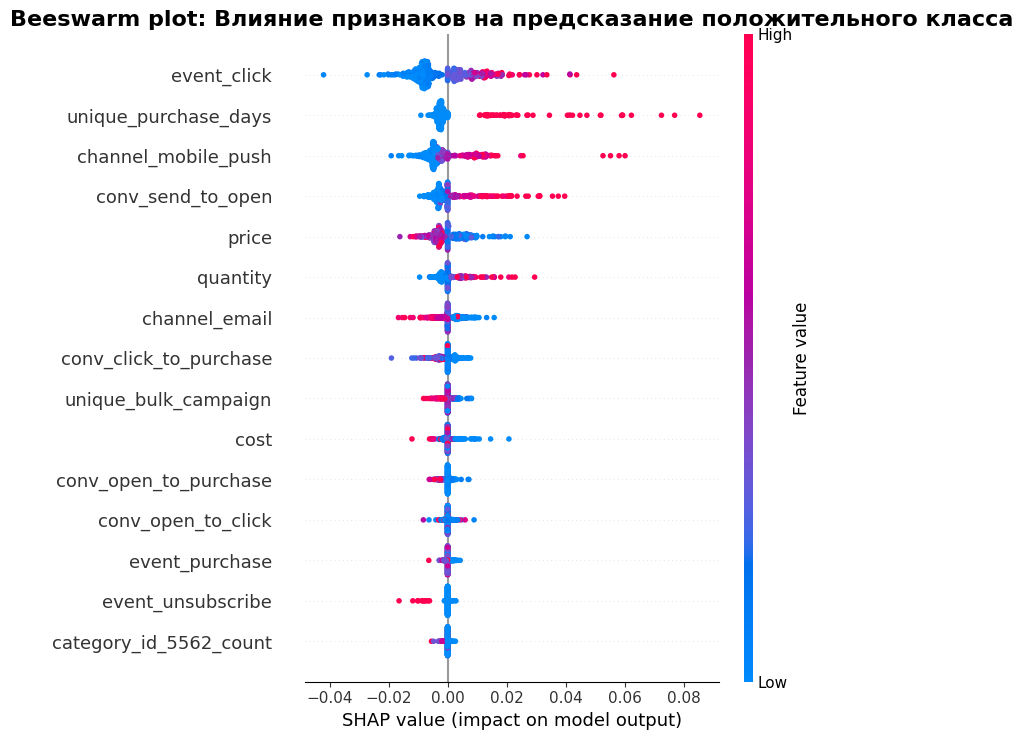

In [137]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_positive, X_test_processed[:400], 
                  feature_names=feature_names, 
                  plot_type='dot',  # beeswarm plot
                  show=False,
                  max_display=15)  # показываем все 15 признаков

plt.title('Beeswarm plot: Влияние признаков на предсказание положительного класса', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Комментарий:**

Анализ beeswarm plot показывает детальную картину влияния признаков на прогноз прихода покупателя:

Положительное влияение на вероятность прихода покупателя оказывают:
- event_click
- nique_purchase_days
- channel_mobile_push
- conv_send_to_open
- quantity

При этом обратная связь с price, что логично.

**Общие выводы по шагу 5:**

5.1-5.3 Настройка и поиск гиперпараметров

Был проведен поиск оптимальных гиперпараметров для трех алгоритмов: RandomForest, XGBoost и CatBoost с использованием RandomizedSearchCV (5-кратная кросс-валидация, 100 итераций, метрика ROC-AUC). Рассматривались различные варианты масштабирования количественных признаков (StandardScaler, MinMaxScaler, RobustScaler, passthrough).

5.4 Результаты оптимизации

Лучшая модель: XGBClassifier со следующими гиперпараметрами:

- preprocessor__quant: RobustScaler()
- classifier__subsample: 0.8
- classifier__scale_pos_weight: 2
- classifier__n_estimators: 50
- classifier__max_depth: 3
- classifier__learning_rate: 0.1
- classifier__colsample_bytree: 0.6

Метрики:

- ROC-AUC на кросс-валидации: 0,7217
- ROC-AUC на тестовой выборке: 0,7405

Небольшое превышение тестовой метрики над CV указывает на хорошую обобщающую способность модели.

5.5 Матрица ошибок

[[12221     2]
 [  240     0]]

Интерпретация:

- True Negative (12221): правильно предсказанные некупившие
- False Positive (2): ложные срабатывания (минимально)
- False Negative (240): пропущенные целевые клиенты (основная проблема)
- True Positive (0): ни одного правильно предсказанного покупателя

Модель хорошо определяет некупивших (пости 100% accuracy по классу 0), но не может обнаружить покупателей из-за сильного дисбаланса классов

5.6 Анализ важности признаков

Permutation Importance (топ-5):

- unique_purchase_days - 0.049
- event_click - 0.042
- conv_send_to_open - 0.018
- price - 0.017
- channel_mobile_push - 0.012

SHAP Analysis подтверждает:

- Положительное влияние: event_click, unique_purchase_days, channel_mobile_push, conv_send_to_open, quantity
- Отрицательное влияние: price (логично — более дорогие товары снижают вероятность покупки)

Ключевые выводы

Лучший алгоритм: XGBoost с RobustScaler показал наилучший результат (ROC-AUC 0,7405)
Проблема дисбаланса классов:

- Модель отлично определяет некупивших (почти 100% accuracy)
- Но не может обнаружить покупателей (0% recall по классу 1) - типичная ситуация для сильно несбалансированных данных

Ключевые признаки:

- Покупательская активность: количество дней с покупками, клики
- Вовлеченность: конверсия send→open, мобильный канал
- Ценовые характеристики: цена товара (обратная связь)

Рекомендации для возможных дальнейших улучшений:

- Применить методы борьбы с дисбалансом (SMOTE, undersampling)
- Настроить порог классификации
- Рассмотреть ансамблирование моделей

**Общие выводы по проекту:**

Цель проекта: Разработка модели машинного обучения для предсказания вероятности совершения покупки клиентом в течение следующих 90 дней на основе истории покупок и взаимодействия с рекламными рассылками.

Основные этапы работы:

Шаг 1-2: Загрузка и предобработка данных

- Загружены и очищены 5 датасетов: apparel-purchases (202 тыс. строк), apparel-messages (12,7 млн строк), target (49,8 тыс. клиентов)
- Удалено дубликатов: 73 тыс. из purchases, 48.6 тыс. из messages
- Обработаны пропуски в категориях (2,6% данных)
- Созданы бинарные признаки для 8 категорий первого уровня
- Выполнена агрегация по клиентам: 49 849 клиентов × 34 признака

Шаг 3: Исследовательский анализ данных

- Выявлен сильный дисбаланс классов: только 1,93% клиентов совершили покупку в целевом периоде
- Обнаружено, что 15,8% клиентов не имеют истории рассылок
- Определены ключевые различия между группами: клиенты с target=1 исторически тратят больше, покупают чаще и активнее взаимодействуют с рассылками
- Выявлена высокая мультиколлинеарность между некоторыми признаками

Шаг 4: Подготовка данных

- Удалено 4 признака с высокой корреляцией (event_send, event_open, unique_messages, has_bulk_campaign)
- Итоговое количество признаков для моделирования: 28
- Данные разделены на train/test (75/25) со стратификацией
- Создан пайплайн предобработки с масштабированием количественных признаков

Шаг 5: Обучение моделей

- Проведен поиск гиперпараметров для RandomForest, XGBoost и CatBoost (RandomizedSearchCV, 5-fold CV, ROC-AUC)
- Лучшая модель: XGBoost с RobustScaler
- ROC-AUC на тесте: 0,7405

Анализ результатов модели

Сильные стороны:

- Модель отлично идентифицирует некупивших (пости 100% accuracy по классу 0)
- Хорошая обобщающая способность (тестовая метрика выше CV)
- Выявлены интерпретируемые закономерности

Слабые стороны:

- Модель не обнаруживает покупателей (0% recall по классу 1)
- Сильный дисбаланс классов (1,93% положительных примеров) не позволяет модели эффективно обучаться на редком событии

Ключевые признаки, влияющие на покупку

- unique_purchase_days - чем больше дней с покупками, тем выше вероятность
- event_click - активные клики по рассылкам — сильный сигнал
- conv_send_to_open	- высокая конверсия открытий указывает на вовлеченность
- channel_mobile_push - мобильный канал эффективен для стимулирования покупок
- price - более дорогие товары снижают вероятность покупки

Рекомендации для бизнеса

Фокус на вовлеченных клиентах:

- Клиенты с высокой исторической активностью (много дней с покупками, частые клики) — наиболее перспективная аудитория
- Стоит усиливать коммуникацию с этой группой

Развитие мобильного канала:

-channel_mobile_push показал значимое положительное влияние — инвестиции в push-уведомления могут повысить конверсию

Ценовая политика:

- Обратная связь с ценой предполагает, что для стимулирования покупок эффективны акции и скидки

Работа с "холодной" аудиторией:

- 15,8% клиентов без истории рассылок — потенциал для вовлечения через персонализированные предложения

Рекомендации для дальнейшего улучшения модели

- Борьба с дисбалансом классов:
    - Применить SMOTE или другие методы синтетической генерации данных
    - Использовать undersampling для балансировки классов
    - Настроить порог классификации для оптимизации recall

Усложнение модели:

- Рассмотреть ансамблирование нескольких моделей
- Использовать stacking или blending
- Попробовать нейросетевые подходы

Итоговый результат

Разработана модель, способная с высокой точностью идентифицировать клиентов, которые не совершат покупку (99.98% accuracy), что позволяет оптимизировать маркетинговые бюджеты, не тратя ресурсы на заведомо нецелевую аудиторию. Однако для выявления потенциальных покупателей требуется дальнейшая работа с дисбалансом классов и настройка порога принятия решений.

Метрика ROC-AUC 0,7405 подтверждает, что модель хорошо ранжирует клиентов по вероятности покупки, что позволяет использовать предсказанные вероятности для таргетирования маркетинговых кампаний.